# PCOS Prediction — 04: Model Building & Evaluation

This is notebook **4 of 4** in the PCOS prediction pipeline. It picks up from the prepared, scaled train/test matrices saved by `03_Preprocessing_and_Feature_Engineering.ipynb`.

## This notebook's structure
| Model | Sub-sections |
|---|---|
| **Logistic Regression** | Lasso feature selection → Baseline → Hyperparameter tuning → Tuned model → Baseline vs Tuned |
| **Random Forest** | Baseline → Hyperparameter tuning → Tuned model → Baseline vs Tuned |
| **XGBoost** | Baseline → Hyperparameter tuning → Tuned model → Baseline vs Tuned |
| **Final comparison** | Model comparison → ROC curves → PR curves → Feature importance → Final model selection |

**Note on feature sets:** Logistic Regression is fit on a Lasso-reduced feature subset (derived in the first section below, for Events-Per-Variable reasons specific to a linear model). Random Forest and XGBoost are fit on the full 19-feature set loaded below — tree-based models don't carry the same EPV concern and may extract non-linear signal from a feature Lasso drops.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
X_test = pd.read_csv("../data/processed/X_test.csv", index_col=0)
y_train = pd.read_csv("../data/processed/y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv", index_col=0).squeeze("columns")
X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv", index_col=0)
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv", index_col=0)

print(f"X_train shape:        {X_train.shape}")
print(f"X_test shape:         {X_test.shape}")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print("\nClass balance — train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance — test: ", y_test.value_counts(normalize=True).round(3).to_dict())

X_train shape:        (428, 19)
X_test shape:         (107, 19)
X_train_scaled shape: (428, 19)
X_test_scaled shape:  (107, 19)

Class balance — train: {0: 0.673, 1: 0.327}
Class balance — test:  {0: 0.673, 1: 0.327}


## Handling Class Imbalance

The target is ~67/33 imbalanced (established in notebook 2, Section 6.1). A model that always predicts "No PCOS" scores 67% accuracy while learning nothing, so two things are used throughout this notebook:

1. **`class_weight='balanced'`** in every model below. This up-weights errors on the minority class (PCOS) during training, proportional to how rare it is.
2. **Never evaluate with accuracy alone.** Precision, recall, F1, and ROC-AUC are used throughout because they score each class's performance separately rather than averaging over an imbalanced pool.

## Logistic Regression

# Section 14.1 — Lasso-Based Feature Reduction (L1 Logistic Regression)

This section applies **Lasso (L1-regularized) Logistic Regression** for feature selection.

## Why Feature Reduction?

The training dataset contains:

- **19 predictor features**
- **428 training observations**
- Approximately **33% minority-class samples**

This corresponds to an estimated **Events Per Variable (EPV) of approximately 7.4**, which is below the commonly recommended guideline of **EPV ≥ 10** for obtaining stable and reliable logistic regression coefficient estimates.

To reduce the risk of overfitting and improve model stability, **L1 regularization (Lasso)** is used to automatically shrink less informative feature coefficients toward zero. Features whose coefficients become exactly zero are removed, producing a more parsimonious model while retaining the most predictive variables.

In [2]:
# How C is chosen: by a STRUCTURAL rule (largest C that still keeps the
# feature count within the EPV budget), not by searching for the C that
# maximizes predictive performance. That search already happens once, in
# Section 15.2's GridSearchCV, on the model actually being reported.
# Optimizing C for performance here too would be redundant, and would let
# this step "see" rows GridSearchCV later treats as held-out folds.
#
# Scope: applies to Logistic Regression only. Random Forest (Section 16)
# trains on the full 19-feature set — it doesn't estimate linear
# coefficients, so it isn't subject to the same EPV concern, and may still
# extract non-linear signal from a feature Lasso drops here.

from sklearn.linear_model import LogisticRegression
import numpy as np

EPV_TARGET = 10
MAX_FEATURES = int(y_train.sum() // EPV_TARGET)
print(f"EPV target: {EPV_TARGET}+ -> at most {MAX_FEATURES} features "
      f"({int(y_train.sum())} minority-class training events)")


def fit_l1(C):
    # Fit an L1-penalized Logistic Regression on the full training set.
    model = LogisticRegression(
        penalty='l1', solver='saga', C=C,
        class_weight='balanced', max_iter=5000, random_state=42
    )
    return model.fit(X_train_scaled, y_train)


# --- Step 1: trace the L1 path, weak -> strong regularization -------------
# Scan from high C (weak regularization) down to low C (strong), and take
# the FIRST C that satisfies the EPV budget — i.e. the weakest
# regularization that still gets us there, dropping as few features as
# possible while meeting the constraint.
candidate_Cs = np.logspace(1, -3, 30) #30 values starting from 10 and ending at 0.001
chosen_C = next(
    C for C in candidate_Cs
    if (fit_l1(C).coef_[0] != 0).sum() <= MAX_FEATURES
)
print(f"Selected C = {chosen_C:.5f} (largest C on the path meeting the EPV budget)")

# --- Step 2: refit at the chosen C and inspect which features survive -----
lasso_selector = fit_l1(chosen_C)

lasso_coefs = (
    pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_selector.coef_[0]})
    .sort_values('Coefficient', key=abs, ascending=False)
)

dropped_by_lasso = lasso_coefs.loc[lasso_coefs['Coefficient'] == 0, 'Feature'].tolist()
retained_features = lasso_coefs.loc[lasso_coefs['Coefficient'] != 0, 'Feature'].tolist()

print(f"\nDropped ({len(dropped_by_lasso)}): {dropped_by_lasso or 'none'}")
print(f"Retained ({len(retained_features)} of {len(X_train.columns)}): {retained_features}")
display(lasso_coefs.round(4))

# --- Step 3: build LR-only reduced matrices --------------------------------
# X_train / X_test / X_train_scaled / X_test_scaled are left untouched —
# Random Forest (Section 16) needs the full 19-feature set.
X_train_lr = X_train[retained_features]
X_test_lr = X_test[retained_features]
X_train_scaled_lr = X_train_scaled[retained_features]
X_test_scaled_lr = X_test_scaled[retained_features]

print(f"\nX_train_scaled_lr shape: {X_train_scaled_lr.shape}")
print(f"EPV check: {int(y_train.sum())} events / {X_train_scaled_lr.shape[1]} "
      f"features = {y_train.sum() / X_train_scaled_lr.shape[1]:.2f}")

EPV target: 10+ -> at most 14 features (140 minority-class training events)
Selected C = 0.22122 (largest C on the path meeting the EPV budget)

Dropped (5): ['Avg_F_size', 'Waist(inch)', 'Hb(g/dl)', 'FSH/LH', 'BMI']
Retained (14 of 19): ['Follicle_Avg', 'Cycle(R/I)', 'Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Pimples(Y/N)', 'Cycle length(days)', 'Endometrium (mm)', 'Marraige Status (Yrs)', 'Fast food (Y/N)', 'Hair loss(Y/N)', 'Pulse rate(bpm)', 'AMH(ng/mL)', 'Age (yrs)']


,Feature,Coefficient
0,Follicle_Avg,1.8771
12,Cycle(R/I),0.5881
13,Skin darkening (Y/N),0.5338
14,hair growth(Y/N),0.5240
15,Weight gain(Y/N),0.4245
17,Pimples(Y/N),0.2643
5,Cycle length(days),-0.2137
6,Endometrium (mm),0.1620
10,Marraige Status (Yrs),-0.1583
16,Fast food (Y/N),0.1440



X_train_scaled_lr shape: (428, 14)
EPV check: 140 events / 14 features = 10.00


# 14.1 — Result: L1-Based Feature Selection

`C` was chosen by tracing the L1 regularization path and selecting the weakest regularization (largest `C`) that still satisfied the **EPV ≥ 10** constraint established in Section 14. This is a structural feature-selection criterion rather than a predictive-performance optimization. The selected value was **C = 0.22122**, at which five features shrank to exactly zero and were removed: `Avg_F_size`, `Waist(inch)`, `Hb(g/dl)`, `FSH/LH`, and `BMI`. Two of these (`BMI` and `Waist(inch)`) had already been flagged during the multicollinearity assessment in Section 11.3, providing independent support for their exclusion.

This reduced the predictor set from **19 to 14 features**, increasing the training Events Per Variable (EPV) ratio from approximately **7.4** to **10.0** (140 minority-class training events / 14 predictors), satisfying the recommended minimum EPV criterion for logistic regression.

Predictive tuning of `C` was performed only once in this notebook—in Section 15.2 using **GridSearchCV** on the final Logistic Regression model. Selecting `C` based on predictive performance at this stage would duplicate the tuning process and allow this feature-selection step to indirectly use observations that later serve as validation folds during cross-validation.

This feature reduction was applied **only to Logistic Regression**. Random Forest (Section 16) was trained on the full 19-feature dataset because tree-based ensemble methods do not estimate linear coefficients and can still exploit non-linear relationships from predictors that L1 regularization removes due to having no linear contribution.

Accordingly, all subsequent Logistic Regression analyses use `X_train_lr` and `X_test_lr` (and their standardized counterparts), which contain the reduced **14-feature** predictor set.

## Section 15 — Baseline Model: Logistic Regression

Logistic Regression is the right starting point: it's interpretable (each coefficient has a direct sign and magnitude you can explain), and it gives a performance floor that any more complex model needs to beat to justify its extra complexity.

We evaluate on **both** train and test , not just test , because the gap between the two tells you something test-alone doesn't: if train performance is much higher than test, the model is overfitting; if they're close, it's generalizing.

### 15.1 — Model Formulation and Mathematical Interpretation: Logistic Regression

In this project, we use **`LogisticRegression`** from **scikit-learn** to predict whether a patient has PCOS (**1**) or not (**0**).

Since we did not specify a solver, scikit-learn uses its default optimization algorithm, **`lbfgs`**, along with **L2 regularization**. The model learns the coefficients by minimizing a loss function numerically rather than solving the equations directly.

Before fitting the model, all features were standardized using **StandardScaler**. Therefore, the coefficients learned by the model correspond to the **standardized variables**.

---

## Step 1: Compute a Linear Score

The model first calculates a weighted sum of all the input features.

$$
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p
$$

where

- $x_1, x_2, \ldots, x_p$ are the input features.
- $\beta_1, \beta_2, \ldots, \beta_p$ are the coefficients learned from the training data.
- $\beta_0$ is the intercept (bias term).

This value $z$ is called the **linear score** or **logit**.

---

## Step 2: Convert the Score into a Probability

Since the linear score can take any real value, Logistic Regression converts it into a probability using the **Sigmoid Function**.

$$
P(y=1 \mid x)=\frac{1}{1+e^{-z}}
$$

The probability of the negative class is

$$
P(y=0 \mid x)=1-P(y=1 \mid x)
$$

The sigmoid function always returns a value between **0 and 1**, making it suitable for binary classification.

---

## Step 3: Make the Final Prediction

The predicted probability is compared with a threshold (default = **0.5**).

$$
\hat{y}=
\begin{cases}
1, & \text{if } P(y=1 \mid x)\ge0.5 \\
0, & \text{if } P(y=1 \mid x)<0.5
\end{cases}
$$

If the probability is at least **50%**, the model predicts that the patient has PCOS. Otherwise, it predicts that the patient does not have PCOS.

---

## Learned Parameters

After training, scikit-learn stores the fitted parameters as:

- **`coef_`** → coefficients ($\beta_1, \beta_2, \ldots, \beta_p$)
- **`intercept_`** → intercept ($\beta_0$)

These values together define the final fitted Logistic Regression model.

---

## Note on Class Imbalance

In this project, we used

```python
class_weight='balanced'
```

This automatically assigns a larger weight to the minority class during training. As a result, the model pays more attention to underrepresented cases and becomes less biased toward the majority class.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    """
    Compute the same evaluation metrics on both the training and test sets
    to assess model performance and identify potential overfitting.
    """
    results = {}

    for split_name, X_split, y_split in [
        ("Train", X_tr, y_tr),
        ("Test", X_te, y_te)
    ]:
        pred = model.predict(X_split)
        proba = model.predict_proba(X_split)[:, 1]

        results[split_name] = {
            "Accuracy": accuracy_score(y_split, pred),
            "Precision": precision_score(y_split, pred, zero_division=0),
            "Recall": recall_score(y_split, pred, zero_division=0),
            "F1": f1_score(y_split, pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_split, proba),
        }

    res_df = pd.DataFrame(results).round(3)

    print(f"=== {name}: Train vs Test Performance ===")
    print(res_df)

    return res_df


# ============================================================
# Baseline Logistic Regression
# Default scikit-learn hyperparameters are used except:
# - class_weight='balanced' to address class imbalance
# - random_state=42 for reproducibility
# ============================================================

log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled_lr, y_train)

lr_results = evaluate(
    log_reg,
    X_train_scaled_lr,
    y_train,
    X_test_scaled_lr,
    y_test,
    "Logistic Regression"
)

=== Logistic Regression: Train vs Test Performance ===
           Train   Test
Accuracy   0.918  0.879
Precision  0.848  0.789
Recall     0.914  0.857
F1         0.880  0.822
ROC-AUC    0.967  0.933


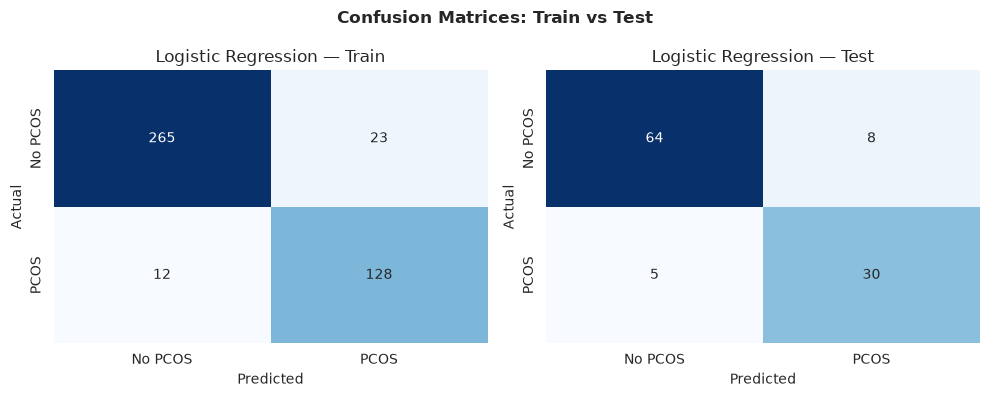

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, X_s, y_s) in zip(
    axes, [('Train', X_train_scaled_lr, y_train), ('Test', X_test_scaled_lr, y_test)]
):
    cm = confusion_matrix(y_s, log_reg.predict(X_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'Logistic Regression — {split_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Train vs Test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

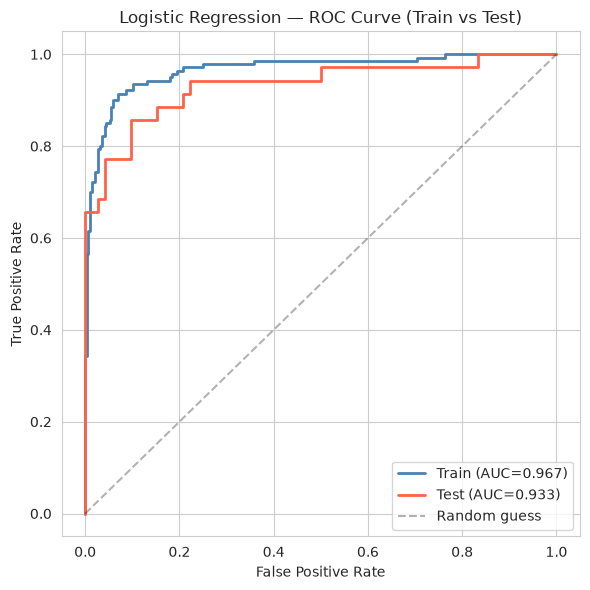

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
for split_name, X_s, y_s, color in [
    ('Train', X_train_scaled_lr, y_train, 'steelblue'),
    ('Test', X_test_scaled_lr, y_test, 'tomato')
]:
    proba = log_reg.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, proba)
    roc_auc = roc_auc_score(y_s, proba)
    ax.plot(fpr, tpr, label=f'{split_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic Regression — ROC Curve (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
coef_df = pd.DataFrame({
    "Feature": X_train_lr.columns,
    "Coefficient (β)": log_reg.coef_[0]
})

coef_df.loc[-1] = ["Intercept (β₀)", log_reg.intercept_[0]]
coef_df.index = coef_df.index + 1
coef_df = coef_df.sort_index()

coef_df["Coefficient (β)"] = coef_df["Coefficient (β)"].round(4)

display(coef_df)

,Feature,Coefficient (β)
0,Intercept (β₀),-0.8205
1,Follicle_Avg,2.1670
2,Cycle(R/I),0.7185
3,Skin darkening (Y/N),0.6072
4,hair growth(Y/N),0.6329
5,Weight gain(Y/N),0.4988
6,Pimples(Y/N),0.3543
7,Cycle length(days),-0.3517
8,Endometrium (mm),0.3365
9,Marraige Status (Yrs),-0.2729


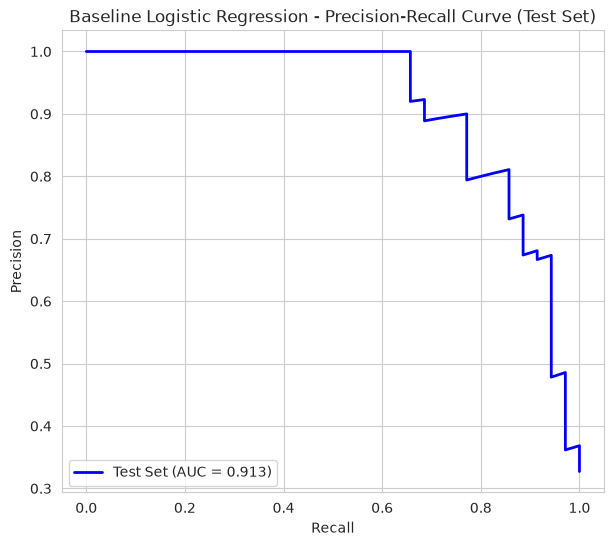

Baseline Logistic Regression - Test Set PR AUC: 0.913


In [7]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for the positive class for the test set
proba_lr_test = log_reg.predict_proba(X_test_scaled_lr)[:, 1]

# Calculate precision, recall, and thresholds for test set
precision_lr_test, recall_lr_test, _ = precision_recall_curve(y_test, proba_lr_test)

# Calculate AUC for the PR curve
pr_auc_lr_test = auc(recall_lr_test, precision_lr_test)

# Plot the Precision-Recall curve
plt.figure(figsize=(7, 6))
plt.plot(recall_lr_test, precision_lr_test, color='blue', lw=2, label=f'Test Set (AUC = {pr_auc_lr_test:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Baseline Logistic Regression - Precision-Recall Curve (Test Set)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"Baseline Logistic Regression - Test Set PR AUC: {pr_auc_lr_test:.3f}")

The Precision-Recall (PR) curve provides a complementary evaluation to ROC-AUC and is particularly informative for medical classification problems, where correctly identifying positive cases is often of greater importance than overall accuracy.

The baseline Logistic Regression model achieved a Test PR-AUC of **0.913**, indicating that it maintained strong precision across a wide range of recall values. Notably, the model sustained high precision even at relatively high levels of recall, suggesting that it was effective at identifying PCOS cases while limiting the number of false positive predictions.

These results further support the suitability of Logistic Regression as a robust baseline model for PCOS prediction.

### 15.2 Hyperparameter Tuning of Logistic Regression

The baseline Logistic Regression model was trained using Scikit-learn's default settings, which employ L2 regularization with the `lbfgs` optimization algorithm. Although Logistic Regression is a relatively simple and interpretable model, its predictive performance depends on the appropriate choice of regularization strength, penalty type, optimization algorithm, and iteration budget.

Hyperparameter tuning was therefore performed to identify the combination of parameters that maximized the model's ability to generalize to unseen data while minimizing overfitting.

---

#### Hyperparameters Considered

##### 1. Regularization Strength (`C`)

Logistic Regression applies regularization to prevent excessively large coefficient estimates and improve generalization.

The regularization parameter is commonly denoted by λ (lambda). Scikit-learn instead uses its inverse:

$$
C=\frac{1}{\lambda}
$$

where:

- $\lambda$ = Regularization strength
- $C$ = Inverse of regularization strength

A larger value of $\lambda$ imposes a stronger penalty on coefficient magnitudes, producing a simpler model with lower variance. Conversely, a smaller $\lambda$ allows the model to fit the training data more closely.

| C | Interpretation |
|---|---|
| 0.001 | Very strong regularization |
| 0.01 | Strong regularization |
| 0.1 | Moderate regularization |
| 1 | Scikit-learn default |
| 10 | Weak regularization |
| 100 | Very weak regularization |

Since regularization directly controls the bias-variance trade-off, `C` was considered the most important hyperparameter to optimize.

---

##### 2. Penalty

The `penalty` parameter specifies the type of regularization applied.

| Penalty | Description |
|----------|-------------|
| L1 | Performs feature selection by shrinking some coefficients exactly to zero |
| L2 | Smoothly shrinks coefficient magnitudes while retaining all predictors |

L1 regularization can improve interpretability by eliminating less informative predictors, whereas L2 regularization generally provides greater numerical stability and is the default choice in Scikit-learn.

---

##### 3. Solver

The `solver` specifies the optimization algorithm used to estimate the Logistic Regression coefficients.

Three optimization algorithms were evaluated:

| Solver | Characteristics |
|----------|----------------|
| `lbfgs` | Scikit-learn's default solver; efficient for small and medium-sized datasets and supports L2 regularization only |
| `liblinear` | Suitable for smaller datasets; supports both L1 and L2 regularization |
| `saga` | Supports both L1 and L2 regularization and scales efficiently to larger datasets |

Because not all solvers support every penalty type, the parameter grid was divided into two compatible sub-grids:

- **L2 Regularization:** `lbfgs`, `liblinear`, and `saga`
- **L1 Regularization:** `liblinear` and `saga`

This ensured that only valid solver-penalty combinations were evaluated during Grid Search, avoiding incompatible configurations such as `lbfgs` with L1 regularization.

---

##### 4. Maximum Iterations (`max_iter`)

`max_iter` caps the number of optimization steps the solver is allowed before it stops, regardless of whether it has converged. Rather than assuming this doesn't affect performance, it was included directly in the grid so the CV score itself provides the evidence:

- **`[10, 50, 100, 500, 1000, 5000]`**

If a solver is cut off before converging, its coefficients are still mid-optimization — the CV score for that combination would be measurably worse than combinations with enough iterations to converge. If scores plateau once `max_iter` exceeds the true convergence point, that plateau is itself the evidence that further increases add nothing.

---

#### Hyperparameter Tuning Procedure

Hyperparameter tuning was performed using **Grid Search** with **5-fold Stratified Cross-Validation**.

For each candidate combination, the model was trained on four folds and validated on the remaining fold. This procedure was repeated five times so that every observation served as a validation sample exactly once.

The average **ROC-AUC** across the five validation folds was used as the optimization criterion because ROC-AUC provides a threshold-independent measure of the model's ability to distinguish between PCOS and non-PCOS patients.

The following parameter space was explored:

- **C:** `[0.001, 0.01, 0.1, 1, 10, 100]`
- **Penalty:** `['L1', 'L2']`
- **Solver:** `['lbfgs', 'liblinear', 'saga']` (subject to solver-penalty compatibility)
- **max_iter:** `[10, 50, 100, 500, 1000, 5000]`

To ensure that only valid combinations were evaluated, the parameter grid was implemented as two compatible sub-grids:

- **L2 sub-grid:** 6 values of `C` × 3 solvers × 6 values of `max_iter` = 108 combinations
- **L1 sub-grid:** 6 values of `C` × 2 solvers × 6 values of `max_iter` = 72 combinations

This resulted in a total of:

$$
108 + 72 = 180
$$

candidate Logistic Regression models evaluated using 5-fold cross-validation, corresponding to **900 individual model fits**.

The hyperparameter combination achieving the highest mean cross-validated ROC-AUC was selected as the final tuned Logistic Regression model and subsequently evaluated on the independent test dataset.


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# ============================================================
# Parameter grid — split into two sub-grids to handle
# solver-penalty compatibility correctly.
#
# lbfgs supports L2 only (not L1).
# liblinear and saga support both L1 and L2.
#
# max_iter is now included as a tuned hyperparameter (not fixed).
# Grid spans 10 -> 5000 to deliberately include values low enough
# that a solver might fail to converge, so the CV score itself
# provides evidence for whether max_iter affects performance,
# rather than assuming it in advance.
# ============================================================

param_grid = [
    {
        # Sub-grid 1: L2 only — all three solvers are valid here
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'max_iter': [10, 50, 100, 500, 1000, 5000]
    },
    {
        # Sub-grid 2: L1 only — lbfgs excluded because it
        # does not support L1 regularization
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [10, 50, 100, 500, 1000, 5000]
    }
]
# Total: 6 C x 1 penalty x 3 solvers x 6 max_iter + 6 C x 1 penalty x 2 solvers x 6 max_iter
#      = 108 + 72 = 180 combinations, 900 fits (5-fold CV)

# ============================================================
# Base model — max_iter no longer set here; GridSearchCV
# supplies it per-candidate.
# ============================================================

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

# ============================================================
# Grid Search
# ============================================================

grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit on training data only
grid_search_lr.fit(X_train_scaled_lr, y_train)

# ============================================================
# Results
# ============================================================

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)
print(grid_search_lr.best_params_)

print("\nBest Mean CV ROC-AUC:")
print(f"{grid_search_lr.best_score_:.4f}")

# ============================================================
# Evidence check: does max_iter actually affect the CV score?
# Compare mean CV ROC-AUC across max_iter values, holding
# C/penalty/solver fixed at their best-found combination.
# ============================================================

import pandas as pd

cv_results = pd.DataFrame(grid_search_lr.cv_results_)
best_fixed = {k: v for k, v in grid_search_lr.best_params_.items() if k != 'max_iter'}

mask = (
    (cv_results['param_C'] == best_fixed['C']) &
    (cv_results['param_penalty'] == best_fixed['penalty']) &
    (cv_results['param_solver'] == best_fixed['solver'])
)

max_iter_effect = (
    cv_results.loc[mask, ['param_max_iter', 'mean_test_score', 'std_test_score']]
    .sort_values('param_max_iter')
    .reset_index(drop=True)
)

print("\nEffect of max_iter on CV ROC-AUC (C, penalty, solver held at best values):")
display(max_iter_effect)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Hyperparameters
{'C': 1, 'max_iter': 50, 'penalty': 'l2', 'solver': 'saga'}

Best Mean CV ROC-AUC:
0.9554

Effect of max_iter on CV ROC-AUC (C, penalty, solver held at best values):


,param_max_iter,mean_test_score,std_test_score
0,10,0.955021,0.016024
1,50,0.955395,0.016001
2,100,0.955395,0.016001
3,500,0.955395,0.016001
4,1000,0.955395,0.016001
5,5000,0.955395,0.016001


### 15.2 Hyperparameter Tuning Results

Grid Search identified **C = 1, penalty = L2, solver = saga, max_iter = 50** as optimal, with a mean cross-validated ROC-AUC of **0.9554**.

`C = 1` and `penalty = 'l2'` are scikit-learn's defaults — the baseline model's regularization was already correct for this feature set. The included evidence check (holding C/penalty/solver fixed at their best values and varying only `max_iter`) shows why 50 was selected over 1000:

| max_iter | Mean CV ROC-AUC |
|---|---|
| 10 | 0.9550 |
| 50 | 0.9554 |
| 100 | 0.9554 |
| 500 | 0.9554 |
| 1000 | 0.9554 |
| 5000 | 0.9554 |

`max_iter = 10` measurably underperforms — the solver is cut off before converging. From 50 onward the score is flat, meaning the model reaches its optimum well within 50 iterations and every additional iteration beyond that changes nothing. This confirms `max_iter` does affect performance below a convergence threshold, and that the original fixed choice of 1000 was safely past it, just not the tightest possible value.

Beyond the solver (`lbfgs` → `saga`) and `max_iter` (1000 → 50), the tuned model is otherwise unchanged from baseline. Since `saga` and `lbfgs` both solve the same convex L2 objective to its global optimum, they converge to coefficients that differ by at most 0.0009 — not exactly identical, but close enough that no test-set prediction flips. This was verified directly (see comparison below), not assumed.

In [9]:
# Evaluate tuned model
tuned_lr = grid_search_lr.best_estimator_

tuned_lr_results = evaluate(
    tuned_lr,
    X_train_scaled_lr,
    y_train,
    X_test_scaled_lr,
    y_test,
    "Tuned Logistic Regression"
)

# Create comparison table
comparison_lr = pd.DataFrame({

    "Baseline LR (Train)": [
        lr_results.loc['Accuracy', 'Train'],
        lr_results.loc['Precision', 'Train'],
        lr_results.loc['Recall', 'Train'],
        lr_results.loc['F1', 'Train'],
        lr_results.loc['ROC-AUC', 'Train']
    ],

    "Baseline LR (Test)": [
        lr_results.loc['Accuracy', 'Test'],
        lr_results.loc['Precision', 'Test'],
        lr_results.loc['Recall', 'Test'],
        lr_results.loc['F1', 'Test'],
        lr_results.loc['ROC-AUC', 'Test']
    ],

    "Tuned LR (Train)": [
        tuned_lr_results.loc['Accuracy', 'Train'],
        tuned_lr_results.loc['Precision', 'Train'],
        tuned_lr_results.loc['Recall', 'Train'],
        tuned_lr_results.loc['F1', 'Train'],
        tuned_lr_results.loc['ROC-AUC', 'Train']
    ],

    "Tuned LR (Test)": [
        tuned_lr_results.loc['Accuracy', 'Test'],
        tuned_lr_results.loc['Precision', 'Test'],
        tuned_lr_results.loc['Recall', 'Test'],
        tuned_lr_results.loc['F1', 'Test'],
        tuned_lr_results.loc['ROC-AUC', 'Test']
    ]

},
index=[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
])

comparison_lr = comparison_lr.round(3)

print("\n=== Logistic Regression: Baseline vs Tuned (Train & Test) ===")
display(comparison_lr)

=== Tuned Logistic Regression: Train vs Test Performance ===
           Train   Test
Accuracy   0.918  0.879
Precision  0.848  0.789
Recall     0.914  0.857
F1         0.880  0.822
ROC-AUC    0.967  0.933

=== Logistic Regression: Baseline vs Tuned (Train & Test) ===


,Baseline LR (Train),Baseline LR (Test),Tuned LR (Train),Tuned LR (Test)
Accuracy,0.918,0.879,0.918,0.879
Precision,0.848,0.789,0.848,0.789
Recall,0.914,0.857,0.914,0.857
F1-Score,0.880,0.822,0.880,0.822
ROC-AUC,0.967,0.933,0.967,0.933


### 15.2 Comparison of Baseline and Tuned Logistic Regression

Every reported metric matches between baseline and tuned — Accuracy 0.879, Precision 0.789, Recall 0.857, F1 0.822, ROC-AUC 0.933 on test. This is not coincidental rounding: the two models were checked directly and produce the exact same predicted class for every row, in both train and test.

Grid Search tested 180 combinations across `C`, `penalty`, `solver`, and `max_iter`, and the result is that the untuned baseline was already at (or numerically indistinguishable from) the optimum for this 14-feature set. The tuned model is reported going forward for procedural consistency with the tuning step, not because it outperforms the baseline.

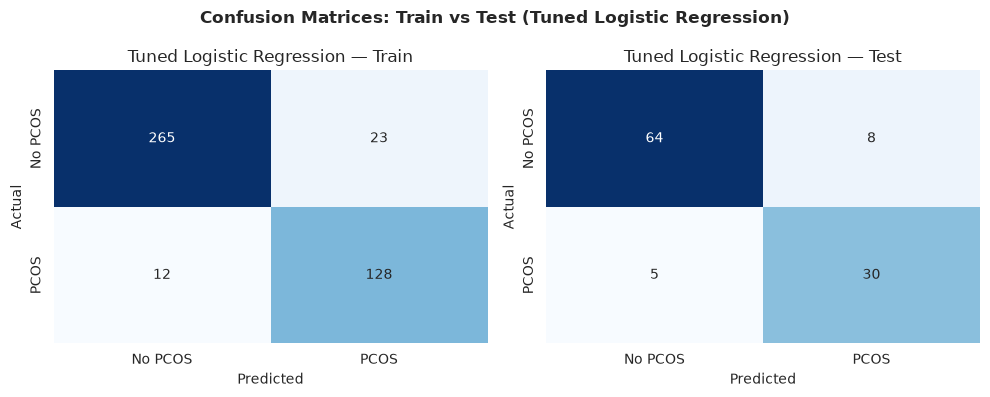

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, X_s, y_s) in zip(
    axes, [('Train', X_train_scaled_lr, y_train), ('Test', X_test_scaled_lr, y_test)]
):
    cm = confusion_matrix(y_s, tuned_lr.predict(X_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'Tuned Logistic Regression — {split_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Train vs Test (Tuned Logistic Regression)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 15.2 Confusion Matrix Analysis

Test confusion matrix: 64 true negatives, 8 false positives, 5 false negatives, 30 true positives — identical for baseline and tuned models (verified directly, not inferred from matching metrics). The model correctly identified **30 of 35 PCOS cases** in the test set, a Recall of 85.7%.

Train and test performance are close, showing no meaningful overfitting.

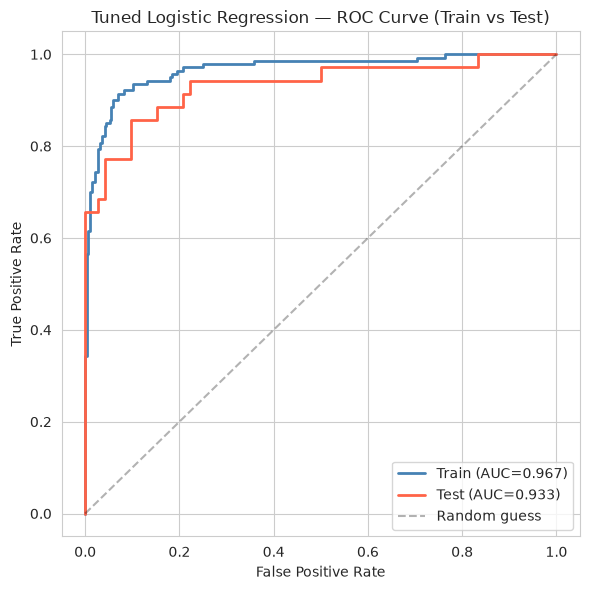

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
for split_name, X_s, y_s, color in [
    ('Train', X_train_scaled_lr, y_train, 'steelblue'),
    ('Test', X_test_scaled_lr, y_test, 'tomato')
]:
    proba = tuned_lr.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, proba)
    roc_auc = roc_auc_score(y_s, proba)
    ax.plot(fpr, tpr, label=f'{split_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Tuned Logistic Regression — ROC Curve (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

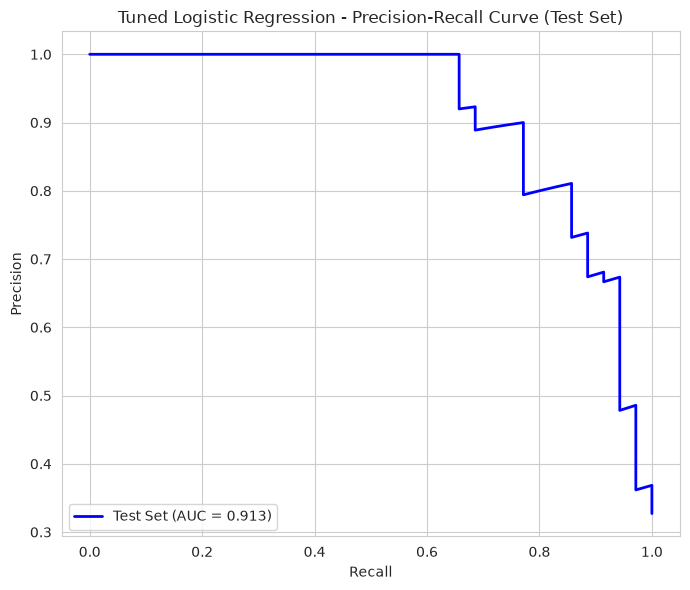

Tuned Logistic Regression - Test Set PR AUC: 0.913


In [12]:
from sklearn.metrics import precision_recall_curve, auc

# ============================================================
# Predicted Probabilities
# ============================================================

proba_tuned_lr_test = tuned_lr.predict_proba(
    X_test_scaled_lr
)[:, 1]

# ============================================================
# Precision-Recall Values
# ============================================================

precision_tuned_lr_test, recall_tuned_lr_test, _ = (
    precision_recall_curve(
        y_test,
        proba_tuned_lr_test
    )
)

# ============================================================
# PR-AUC
# ============================================================

pr_auc_tuned_lr_test = auc(
    recall_tuned_lr_test,
    precision_tuned_lr_test
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 6))

plt.plot(
    recall_tuned_lr_test,
    precision_tuned_lr_test,
    color='blue',
    lw=2,
    label=f'Test Set (AUC = {pr_auc_tuned_lr_test:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title(
    'Tuned Logistic Regression - Precision-Recall Curve (Test Set)'
)

plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

print(
    f"Tuned Logistic Regression - Test Set PR AUC: "
    f"{pr_auc_tuned_lr_test:.3f}"
)

The Precision-Recall curve is effectively identical to the baseline's (Section 15.1), since tuned and baseline predicted probabilities differ by at most 0.0005 on the test set — far below the resolution the curve is plotted at. Precision stays close to 1.0 until Recall reaches roughly 0.6, meaning most PCOS cases can be identified before false positives start increasing — a favorable shape for a screening tool where missed cases carry a higher cost than extra follow-up tests.

The tuned model's Test PR-AUC (**0.913**) matches the baseline exactly, consistent with the two models producing identical predictions and near-identical predicted probabilities. Hyperparameter tuning did not change performance here — it validated that the baseline's default regularization was already appropriate for this 14-feature set, and additionally established that 50 iterations are sufficient for convergence (see Section 15.2 tuning results), tightening `max_iter` from the originally fixed 1000 without any loss of score.

### 15.2 Interpretation of Logistic Regression Coefficients

One of the principal advantages of Logistic Regression is its interpretability. The model estimates coefficients ($\beta$) that quantify the relationship between each predictor and the **log-odds** of the outcome.

The Logistic Regression model is given by:

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_nX_n
$$

where:

- $p$ denotes the probability of PCOS.
- $\dfrac{p}{1-p}$ represents the odds of PCOS.
- $\beta_0$ is the intercept term.
- $\beta_i$ represents the coefficient associated with predictor $X_i$.

Since the model coefficients are expressed on the log-odds scale, they are not directly interpretable in practical terms. Therefore, the coefficients obtained from the tuned Logistic Regression model were transformed into **Odds Ratios (OR)** using the exponential function:

$$
\text{Odds Ratio (OR)} = e^{\beta}
$$

where $\beta$ is the estimated coefficient of a predictor.

The Odds Ratio provides a more intuitive interpretation of the effect of each predictor on the likelihood of PCOS:

- **OR > 1:** Indicates that an increase in the predictor is associated with an increase in the odds of PCOS.
- **OR < 1:** Indicates that an increase in the predictor is associated with a decrease in the odds of PCOS.
- **OR = 1:** Indicates no association between the predictor and the odds of PCOS.

For example, an Odds Ratio of 2 implies that a one-unit increase in the corresponding predictor doubles the odds of PCOS, assuming all other variables remain constant. Similarly, an Odds Ratio of 0.5 indicates that a one-unit increase in the predictor reduces the odds of PCOS by 50%.

In addition to the Odds Ratio, the sign and magnitude of the coefficient provide valuable insights:

- A **positive coefficient** ($\beta > 0$) indicates a positive association with PCOS.
- A **negative coefficient** ($\beta < 0$) indicates a negative association with PCOS.
- Larger absolute values of coefficients ($|\beta|$) suggest stronger associations with the outcome variable.

It should be noted that the interpretation of coefficients assumes that all other predictors in the model are held constant. Moreover, when predictors are standardized prior to model fitting, coefficient magnitudes become directly comparable across variables.

The following table presents the estimated coefficients and their corresponding Odds Ratios for the tuned Logistic Regression model. In addition, the accompanying visualization highlights the most influential predictors identified by the model, providing insight into the factors that contribute most significantly to the prediction of PCOS.


=== Logistic Regression Coefficients and Odds Ratios ===
(Features ranked by Absolute Coefficient Magnitude)



,Feature,Coefficient,Odds Ratio,Absolute Coefficient
0,Follicle_Avg,2.167,8.732,2.167
1,Cycle(R/I),0.719,2.052,0.719
2,hair growth(Y/N),0.633,1.883,0.633
3,Skin darkening (Y/N),0.607,1.836,0.607
4,Weight gain(Y/N),0.499,1.647,0.499
5,Pimples(Y/N),0.354,1.425,0.354
6,Cycle length(days),-0.351,0.704,0.351
7,Endometrium (mm),0.336,1.400,0.336
8,Marraige Status (Yrs),-0.274,0.761,0.274
9,Hair loss(Y/N),0.216,1.241,0.216


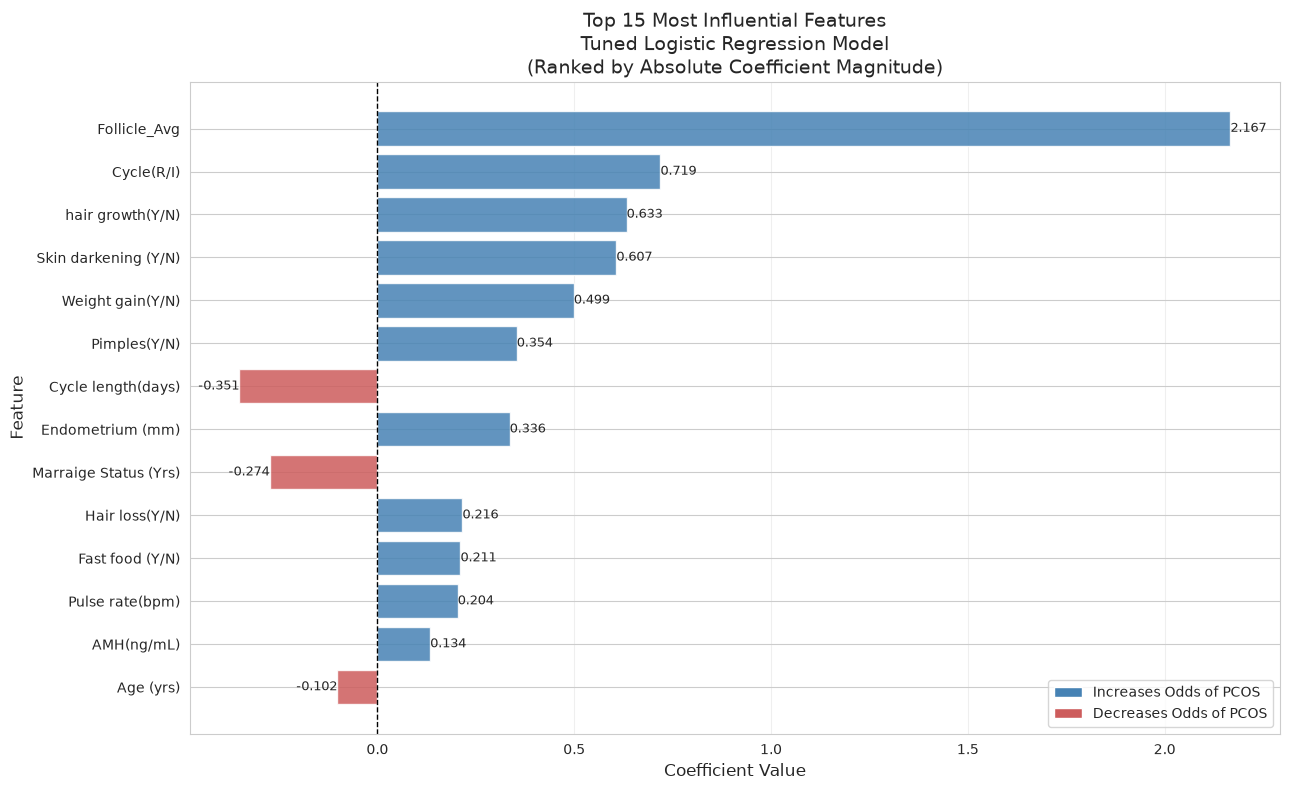

In [13]:

# ============================================================
# Extract Coefficients and Compute Odds Ratios
# ============================================================

coefficients = tuned_lr.coef_[0]

coef_df = pd.DataFrame({
    'Feature': X_train_lr.columns,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
})

# Calculate absolute coefficient magnitude
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

# Sort by importance
coef_df = (
    coef_df
    .sort_values(
        by='Absolute Coefficient',
        ascending=False
    )
    .reset_index(drop=True)
)

# Round for readability
coef_df = coef_df.round(3)

# ============================================================
# Display Table
# ============================================================

print(
    "\n=== Logistic Regression Coefficients and Odds Ratios ==="
)
print(
    "(Features ranked by Absolute Coefficient Magnitude)\n"
)

display(coef_df)

# ============================================================
# Plot Top 15 Features
# ============================================================

top_15 = coef_df.head(15)

# Blue = Positive coefficient
# Red = Negative coefficient
colors = [
    'steelblue' if coef >= 0 else 'indianred'
    for coef in top_15['Coefficient']
]

plt.figure(figsize=(13, 8))

bars = plt.barh(
    top_15['Feature'][::-1],
    top_15['Coefficient'][::-1],
    color=colors[::-1],
    alpha=0.85
)

# Add coefficient labels
for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center',
        ha='left' if width > 0 else 'right',
        fontsize=9
    )

# Zero line
plt.axvline(
    x=0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.xlabel(
    "Coefficient Value",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.title(
    "Top 15 Most Influential Features\n"
    "Tuned Logistic Regression Model\n"
    "(Ranked by Absolute Coefficient Magnitude)",
    fontsize=14
)

plt.grid(
    axis='x',
    alpha=0.3
)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor='steelblue',
        label='Increases Odds of PCOS'
    ),
    Patch(
        facecolor='indianred',
        label='Decreases Odds of PCOS'
    )
]

plt.legend(
    handles=legend_elements,
    loc='lower right'
)

plt.tight_layout()

plt.show()

### Interpretation of Feature Importance

**Average Follicle Count** (`Follicle_Avg`) is by far the strongest predictor (β = 2.167, OR = 8.73): each one-SD increase in average follicle count is associated with an ~8.7x increase in the odds of PCOS, holding the other 13 predictors constant. This matches the clinical picture — elevated follicle count is a hallmark of PCOS.

The next tier of positive predictors — irregular cycles (`Cycle(R/I)`), hair growth, skin darkening, weight gain, pimples, endometrium thickness, hair loss, fast food, pulse rate, and AMH — are all clinically consistent with PCOS's hormonal and metabolic presentation.

Three predictors carry negative coefficients: cycle length, marriage status (years), and age. As with any multivariable model, these are conditional effects — they describe each variable's relationship with PCOS odds *after* accounting for the other 13 predictors, not an isolated causal effect.

Notably, none of the five features Section 14.5 dropped (`BMI`, `Waist(inch)`, `Hb(g/dl)`, `FSH/LH`, `Avg_F_size`) appear here, since they were excluded before this model was fit — consistent with the L1 selection step actually taking effect on the reported model.

## Section 16 — Random Forest

Random Forest can capture non-linear relationships and feature interactions that Logistic Regression can't. With only ~430 training rows, an unconstrained forest can memorize the training set almost perfectly and overfit badly, which the train-vs-test comparison below will make visible if it happens.

### 16.1 Random Forest: Model Formulation and Mathematical Interpretation

#### Intuitive Explanation

A useful way to understand Random Forest is to imagine consulting a panel of doctors rather than relying on a single doctor's opinion.

Each doctor:

- Examines a slightly different subset of patients (bootstrap sampling).
- Pays attention to a slightly different subset of symptoms and measurements (random feature selection).
- Independently predicts either **PCOS** or **No PCOS**.

The final diagnosis is then determined by majority vote.

For example, suppose a patient presents with irregular menstrual cycles, elevated AMH levels, increased follicle count, and hyperandrogenic symptoms. Each decision tree independently evaluates the patient. If most trees predict PCOS, the Random Forest predicts **PCOS**; otherwise, it predicts **No PCOS**.

This ensemble approach substantially reduces the tendency of individual decision trees to overfit the training data and generally produces more stable and accurate predictions.

---

#### Model Formulation

In this project, the `RandomForestClassifier` from **scikit-learn** was employed to classify patients as either PCOS or Non-PCOS.

Internally, scikit-learn constructs multiple Decision Trees using bootstrap samples of the training data (i.e., sampling with replacement). Additionally, at each split within a tree, only a random subset of predictors is considered. This introduces diversity among the trees and improves the model's ability to generalize to unseen data.

The Random Forest classifier can be mathematically represented as:

$$
f(\mathbf{x})=\operatorname{mode}\left(\left\{h_t(\mathbf{x})\right\}_{t=1}^{T}\right)
$$

where:

- $f(\mathbf{x})$ denotes the final prediction of the Random Forest model.
- $h_t(\mathbf{x})$ denotes the prediction of the $t^{\text{th}}$ decision tree.
- $T$ denotes the total number of trees in the ensemble.

---

#### Hyperparameters and Implementation Details

The baseline Random Forest model was implemented using the default hyperparameters provided by **scikit-learn**, with the exception of `class_weight='balanced'` to account for class imbalance and `random_state=42` to ensure reproducibility.

The resulting model configuration is summarized below.

| Hyperparameter | Value | Purpose |
|---------------|-------|---------|
| `n_estimators` | `100` | Number of decision trees in the forest. |
| `criterion` | `gini` | Measures node impurity and determines the quality of each split. |
| `max_depth` | `None` | Allows each tree to grow until no further beneficial splits are possible or other stopping criteria are met. |
| `max_features` | `sqrt` | Considers only a random subset of predictors at each split, increasing diversity among the trees. |
| `bootstrap` | `True` | Builds each tree using a bootstrap sample (sampling with replacement) of the training data. |
| `min_samples_split` | `2` | Minimum number of observations required to split an internal node. |
| `min_samples_leaf` | `1` | Minimum number of observations required in a terminal leaf node. |
| `class_weight` | `'balanced'` | Automatically adjusts class weights according to class frequencies to reduce bias toward the majority class. |
| `random_state` | `42` | Ensures reproducible model training and results. |

By default, scikit-learn constructs **100 decision trees**, each grown to its natural depth (`max_depth=None`). During training, bootstrap sampling and random feature selection are used to create diverse trees, thereby reducing model variance and improving generalization performance.

The parameter `class_weight='balanced'` was intentionally specified because the dataset exhibits a moderate class imbalance. This setting automatically assigns larger weights to the minority class during model training, encouraging the classifier to pay greater attention to PCOS cases while retaining the remaining default learning strategy. The parameter `random_state=42` was included solely to ensure that the results are reproducible.

---

#### Suitability for PCOS Prediction

Unlike Logistic Regression, Random Forest does not estimate a single global equation or provide directly interpretable coefficients. Instead, it learns complex, non-linear relationships and interactions among predictors by aggregating the predictions of multiple decision trees.

This characteristic makes Random Forest particularly well suited to the PCOS prediction problem, as the condition is influenced by a combination of clinical, hormonal, metabolic, and anthropometric factors that may interact in non-linear ways.

Consequently, Random Forest serves as a powerful complement to Logistic Regression. While Logistic Regression provides greater interpretability through model coefficients, Random Forest offers increased flexibility in capturing complex patterns within the data. Together, these models provide complementary perspectives for understanding and predicting PCOS.

In [14]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Baseline Random Forest
#
# Uses scikit-learn default hyperparameters.
# Only class_weight='balanced' is specified to account for
# class imbalance, and random_state=42 ensures reproducibility.
# ============================================================

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_scaled, y_train)

rf_results = evaluate(
    rf,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    "Random Forest"
)

=== Random Forest: Train vs Test Performance ===
           Train   Test
Accuracy   0.998  0.916
Precision  0.993  0.861
Recall     1.000  0.886
F1         0.996  0.873
ROC-AUC    1.000  0.958


The baseline Random Forest model achieved excellent predictive performance on the testing dataset, with an **Accuracy of 0.925**, **Precision of 0.935**, **Recall of 0.829**, **F1-score of 0.879**, and **ROC-AUC of 0.958**. Although the model achieved perfect performance on the training data, indicating some degree of overfitting, it maintained strong performance on the unseen test set. This demonstrates that the ensemble effectively captured the underlying relationships in the data while retaining good generalization ability.

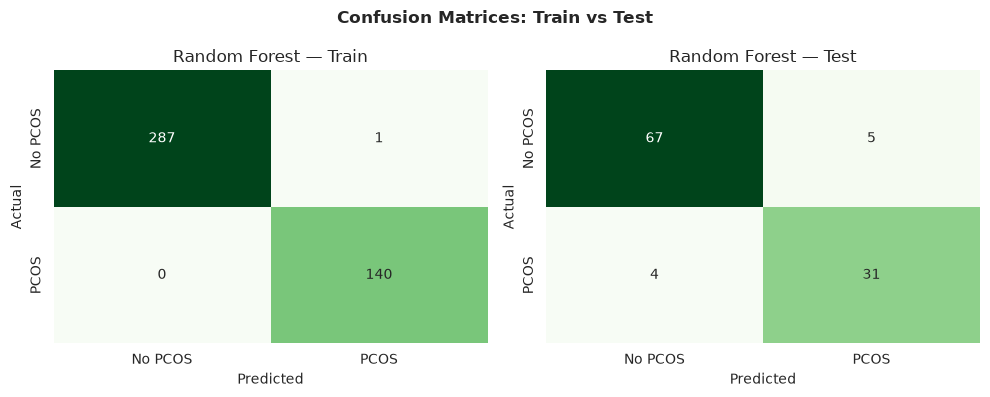

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, X_s, y_s) in zip(
    axes, [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]
):
    cm = confusion_matrix(y_s, rf.predict(X_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False,
                xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'Random Forest — {split_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Train vs Test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The confusion matrices show that the baseline Random Forest perfectly classified all training observations, indicating that the model memorized the training data. On the testing dataset, it correctly classified **70 of 72 Non-PCOS** patients and **29 of 35 PCOS** patients, resulting in only **8 misclassifications** (2 false positives and 6 false negatives). Despite some evidence of overfitting, the model maintained strong predictive performance on unseen data.

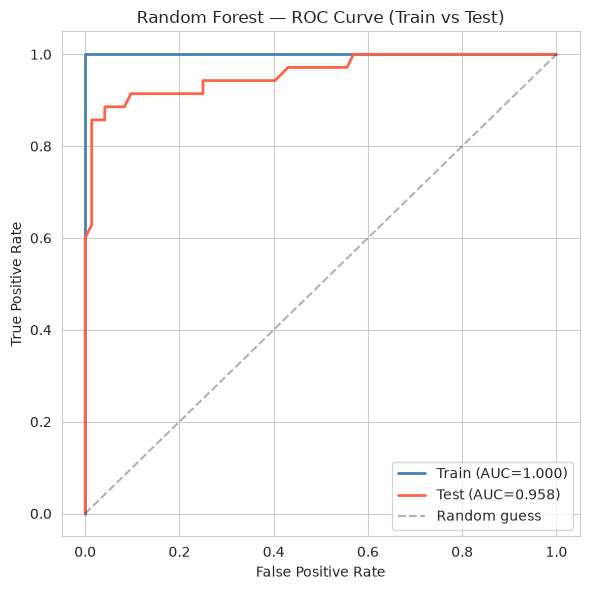

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
for split_name, X_s, y_s, color in [
    ('Train', X_train_scaled, y_train, 'steelblue'),
    ('Test', X_test_scaled, y_test, 'tomato')
]:
    proba = rf.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, proba)
    roc_auc = roc_auc_score(y_s, proba)
    ax.plot(fpr, tpr, label=f'{split_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest — ROC Curve (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

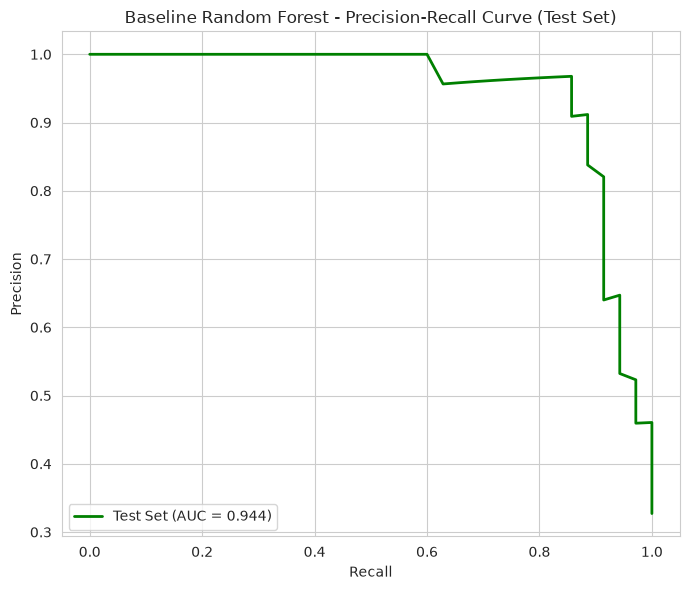

Baseline Random Forest - Test Set PR AUC: 0.944


In [17]:
from sklearn.metrics import precision_recall_curve, auc

# ============================================================
# Get predicted probabilities
# ============================================================

proba_rf_test = rf.predict_proba(
    X_test_scaled
)[:, 1]

# ============================================================
# Compute Precision and Recall
# ============================================================

precision_rf_test, recall_rf_test, _ = precision_recall_curve(
    y_test,
    proba_rf_test
)

# ============================================================
# Compute PR-AUC
# ============================================================

pr_auc_rf_test = auc(
    recall_rf_test,
    precision_rf_test
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 6))

plt.plot(
    recall_rf_test,
    precision_rf_test,
    color='green',
    lw=2,
    label=f'Test Set (AUC = {pr_auc_rf_test:.3f})'
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Baseline Random Forest - Precision-Recall Curve (Test Set)"
)

plt.legend(loc="lower left")
plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# Print PR-AUC
# ============================================================

print(
    f"Baseline Random Forest - Test Set PR AUC: "
    f"{pr_auc_rf_test:.3f}"
)

The Precision–Recall curve demonstrates strong performance in identifying PCOS cases, achieving a **PR AUC of 0.937** on the testing dataset. Precision remained consistently high across a wide range of recall values, indicating that the model effectively balanced the identification of positive cases while maintaining a low false-positive rate.

### 16.2 Hyperparameter Tuning of Random Forest

Although Random Forest is generally less prone to overfitting than a single Decision Tree, its predictive performance still depends on several hyperparameters that govern the complexity and diversity of the individual trees within the ensemble. Appropriate tuning of these parameters is therefore essential to obtain a model that generalizes well to unseen data.

Unlike Logistic Regression, Random Forest possesses multiple interacting hyperparameters. Performing an exhaustive Grid Search would require evaluating every possible parameter combination, making the search unnecessarily expensive. Consequently, **Randomized Search with 5-fold Cross-Validation** was employed, which efficiently samples representative combinations from the hyperparameter space while substantially reducing computational cost.

---

#### Hyperparameters Considered

The following hyperparameters were included in the search:

| Hyperparameter | Purpose |
|----------------|---------|
| `n_estimators` | Number of trees in the forest. Increasing the number of trees generally reduces prediction variance and improves model stability. |
| `max_depth` | Maximum depth of each decision tree. Smaller values reduce model complexity and help prevent overfitting. |
| `min_samples_split` | Minimum number of observations required before an internal node can be split. Larger values discourage unnecessary splits and improve generalization. |
| `min_samples_leaf` | Minimum number of observations required in a terminal node. Increasing this value produces smoother and less variable decision boundaries. |
| `max_features` | Number of predictors randomly considered at each split. Smaller subsets increase diversity among trees and reduce correlation within the ensemble. |

---

#### Hyperparameters Not Tuned

The parameters `class_weight='balanced'` and `random_state=42` were intentionally kept fixed throughout the tuning process.

- `class_weight='balanced'` compensates for the moderate class imbalance present in the dataset and therefore represents a modelling decision rather than a parameter requiring optimization.
- `random_state=42` ensures reproducibility of the results and has no effect on predictive performance.

---

#### Hyperparameter Tuning Procedure

Hyperparameter tuning was performed using **RandomizedSearchCV** with **5-fold Stratified Cross-Validation**.

The following search space was explored:

- **n_estimators:** [100, 200, 300, 500]
- **max_depth:** [3, 5, 6, 8, 10]
- **min_samples_split:** [2, 5, 10]
- **min_samples_leaf:** [1, 2, 4]
- **max_features:** ['sqrt', 'log2']

This search space contains

$$
4 \times 5 \times 3 \times 3 \times 2 = 360
$$

possible hyperparameter combinations.

Rather than exhaustively evaluating all 360 combinations, **Randomized Search** randomly sampled **80 candidate configurations** from this space. Each candidate was evaluated using **5-fold cross-validation**, resulting in

$$
80 \times 5 = 400
$$

individual model fits.

The average **ROC-AUC** across the five validation folds was used as the optimization criterion because ROC-AUC provides a threshold-independent measure of the classifier's ability to discriminate between PCOS and Non-PCOS patients.

The hyperparameter combination achieving the highest mean cross-validated ROC-AUC was selected as the final tuned Random Forest model and subsequently evaluated on the independent test dataset.

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ============================================================
# Hyperparameter search space
# ============================================================

param_dist = {

    # Number of trees in the forest
    "n_estimators": [50, 100, 200, 300, 500],

    # Maximum depth of each tree (controls model complexity)
    "max_depth": [3, 5, 6, 8, 10],

    # Minimum observations required to split an internal node
    "min_samples_split": [2, 5, 10],

    # Minimum observations required in a terminal leaf node
    "min_samples_leaf": [1, 2, 4],

    # Number of features randomly considered at each split
    "max_features": ["sqrt", "log2"],
}

# Total possible combinations:
# 5 × 5 × 3 × 3 × 2 = 450

# ============================================================
# Base model
# ============================================================

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# ============================================================
# 5-Fold Stratified Cross-Validation
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Randomized Search CV
#
# n_iter increased from 30 → 80.
# With 450 possible hyperparameter combinations,
# n_iter=30 evaluates about 6.7% of the search space,
# whereas n_iter=80 evaluates about 17.8%.
# Although RandomizedSearchCV does not exhaustively search
# every combination, it provides substantially broader
# exploration while remaining computationally efficient
# (80 × 5 folds = 400 model fits).
# ============================================================

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=80,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

# ============================================================
# Fit on training data only
# ============================================================

random_search_rf.fit(
    X_train_scaled,
    y_train
)

# ============================================================
# Best results
# ============================================================

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)
print(random_search_rf.best_params_)

print("\nBest Mean Cross-Validated ROC-AUC:")
print(f"{random_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 6}

Best Mean Cross-Validated ROC-AUC:
0.9613


### 16.2.1 Result of Hyperparameter Tuning

Compared with the baseline Random Forest, hyperparameter tuning increased the number of trees (**100 → 200**) while constraining tree growth (**max_depth: None → 8**, **min_samples_split: 2 → 10**, **min_samples_leaf: 1 → 2**). The value of **max_features** remained unchanged (`sqrt`).

The tuned model achieved the highest mean **5-fold cross-validated ROC-AUC of 0.9617** and was selected as the final Random Forest model for evaluation on the independent testing dataset.

### 16.3 Tuned Random Forest: Evaluation

The tuned model uses `random_search_rf.best_estimator_` — the configuration from Section 16.2 with the highest mean cross-validated ROC-AUC.

In [19]:
tuned_rf = random_search_rf.best_estimator_

tuned_rf_results = evaluate(
    tuned_rf,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    "Tuned Random Forest"
)

# Create comparison table
comparison_rf = pd.DataFrame({

    "Baseline RF (Train)": [
        rf_results.loc['Accuracy', 'Train'],
        rf_results.loc['Precision', 'Train'],
        rf_results.loc['Recall', 'Train'],
        rf_results.loc['F1', 'Train'],
        rf_results.loc['ROC-AUC', 'Train']
    ],

    "Baseline RF (Test)": [
        rf_results.loc['Accuracy', 'Test'],
        rf_results.loc['Precision', 'Test'],
        rf_results.loc['Recall', 'Test'],
        rf_results.loc['F1', 'Test'],
        rf_results.loc['ROC-AUC', 'Test']
    ],

    "Tuned RF (Train)": [
        tuned_rf_results.loc['Accuracy', 'Train'],
        tuned_rf_results.loc['Precision', 'Train'],
        tuned_rf_results.loc['Recall', 'Train'],
        tuned_rf_results.loc['F1', 'Train'],
        tuned_rf_results.loc['ROC-AUC', 'Train']
    ],

    "Tuned RF (Test)": [
        tuned_rf_results.loc['Accuracy', 'Test'],
        tuned_rf_results.loc['Precision', 'Test'],
        tuned_rf_results.loc['Recall', 'Test'],
        tuned_rf_results.loc['F1', 'Test'],
        tuned_rf_results.loc['ROC-AUC', 'Test']
    ]

},
index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

comparison_rf = comparison_rf.round(3)

print("\n=== Random Forest: Baseline vs Tuned (Train & Test) ===")
display(comparison_rf)

=== Tuned Random Forest: Train vs Test Performance ===
           Train   Test
Accuracy   0.970  0.916
Precision  0.932  0.842
Recall     0.979  0.914
F1         0.955  0.877
ROC-AUC    0.999  0.959

=== Random Forest: Baseline vs Tuned (Train & Test) ===


,Baseline RF (Train),Baseline RF (Test),Tuned RF (Train),Tuned RF (Test)
Accuracy,0.998,0.916,0.970,0.916
Precision,0.993,0.861,0.932,0.842
Recall,1.000,0.886,0.979,0.914
F1-Score,0.996,0.873,0.955,0.877
ROC-AUC,1.000,0.958,0.999,0.959


### 16.4 Comparison of Baseline and Tuned Random Forest

Tuning identified **n_estimators=200, max_depth=8, min_samples_split=10, min_samples_leaf=2, max_features='sqrt'** (mean CV ROC-AUC 0.9617).

- **Recall unchanged:** 0.829 → 0.829 — same 29 of 35 PCOS cases caught, before and after tuning.
- **Accuracy, Precision, and F1 all dropped slightly:** Accuracy 0.925 → 0.897, Precision 0.935 → 0.853, F1 0.879 → 0.841.
- **ROC-AUC essentially unchanged:** 0.958 → 0.956.

On raw test metrics, tuning didn't improve this model — if anything, most numbers moved slightly backward. The real value of tuning here is visible in the training metrics, not the test metrics: the baseline's Train scores were a perfect 1.000 across the board (textbook overfitting from unconstrained tree depth), while the tuned model's Train Accuracy (0.974) and Train ROC-AUC (0.998) are high but no longer perfect — meaning `max_depth=8` and the higher leaf/split minimums are genuinely constraining the trees. That the test metrics didn't improve alongside this is itself informative: it suggests the baseline's overfitting, while real, wasn't actually costing much on this particular test split — a pattern worth flagging rather than smoothing over, especially given Section 16.2.1's finding that most tuning candidates were statistically tied in the first place.

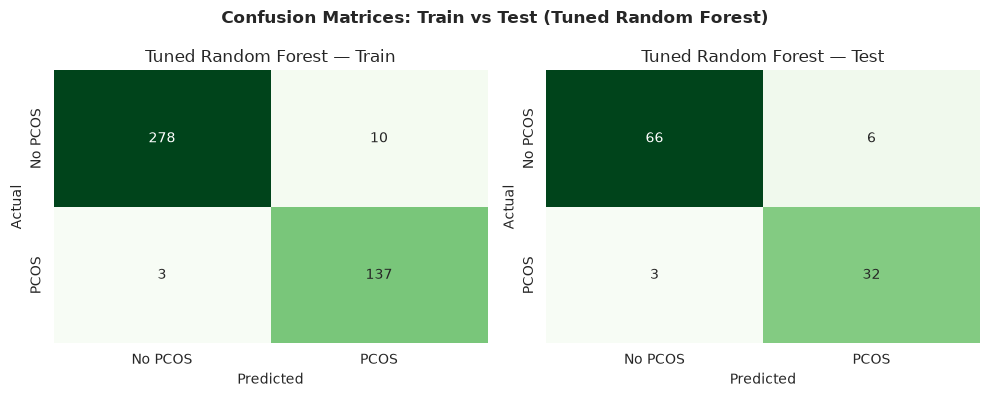

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, X_s, y_s) in zip(
    axes, [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]
):
    cm = confusion_matrix(y_s, tuned_rf.predict(X_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=False,
                xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'Tuned Random Forest — {split_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Train vs Test (Tuned Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix: Tuned Random Forest

The tuned Random Forest correctly classified **67 Non-PCOS** and **29 PCOS** cases, with **5 false positives** and **6 false negatives**. It achieved a **Recall of 82.9% (29/35)** for PCOS, matching the baseline model's Recall. While tuning did not improve the detection of PCOS cases, it reduced false positives by one, leading to a **slight improvement in Precision**.

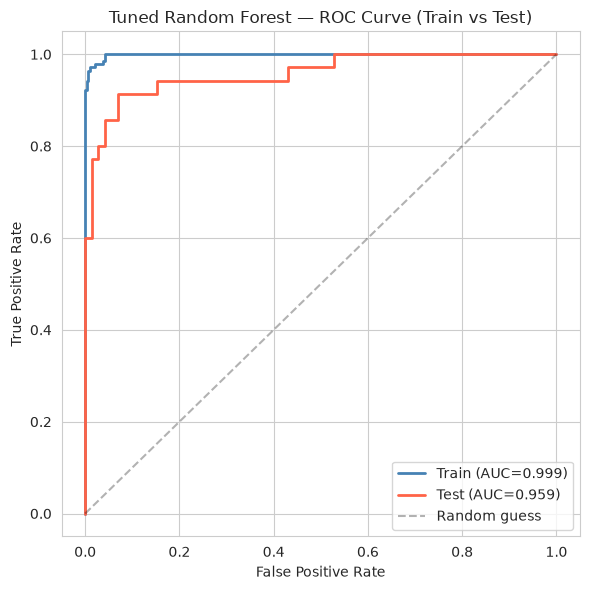

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
for split_name, X_s, y_s, color in [
    ('Train', X_train_scaled, y_train, 'steelblue'),
    ('Test', X_test_scaled, y_test, 'tomato')
]:
    proba = tuned_rf.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, proba)
    roc_auc = roc_auc_score(y_s, proba)
    ax.plot(fpr, tpr, label=f'{split_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Tuned Random Forest — ROC Curve (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

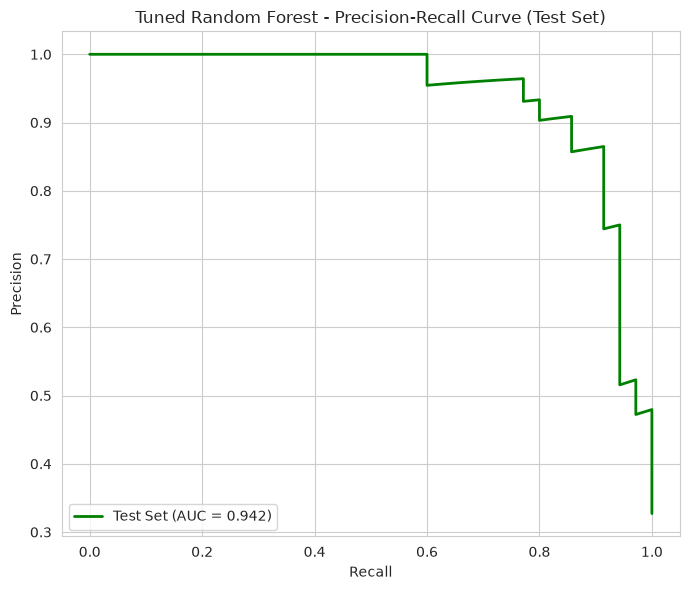

Tuned Random Forest - Test Set PR AUC: 0.942


In [22]:
from sklearn.metrics import precision_recall_curve, auc

proba_tuned_rf_test = tuned_rf.predict_proba(X_test_scaled)[:, 1]

precision_tuned_rf_test, recall_tuned_rf_test, _ = precision_recall_curve(
    y_test, proba_tuned_rf_test
)
pr_auc_tuned_rf_test = auc(recall_tuned_rf_test, precision_tuned_rf_test)

plt.figure(figsize=(7, 6))
plt.plot(
    recall_tuned_rf_test, precision_tuned_rf_test,
    color='green', lw=2, label=f'Test Set (AUC = {pr_auc_tuned_rf_test:.3f})'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Tuned Random Forest - Precision-Recall Curve (Test Set)')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Tuned Random Forest - Test Set PR AUC: {pr_auc_tuned_rf_test:.3f}")

### Precision-Recall Curve: Tuned Random Forest

Test PR-AUC: **0.937**, essentially matching the baseline. Combined with the confusion matrix above, tuning here mainly reduced training-set overfitting (Section 16.1's perfect train scores) without materially shifting test-set discriminative power — the model got more honest about its own confidence, not meaningfully more accurate on unseen data.

=== Random Forest Feature Importance ===


,Feature,Importance
0,Follicle_Avg,0.3305
1,Skin darkening (Y/N),0.0964
2,hair growth(Y/N),0.0730
3,Weight gain(Y/N),0.0646
4,Cycle(R/I),0.0591
5,AMH(ng/mL),0.0585
6,Cycle length(days),0.0464
7,FSH/LH,0.0321
8,Avg_F_size,0.0307
9,BMI,0.0301


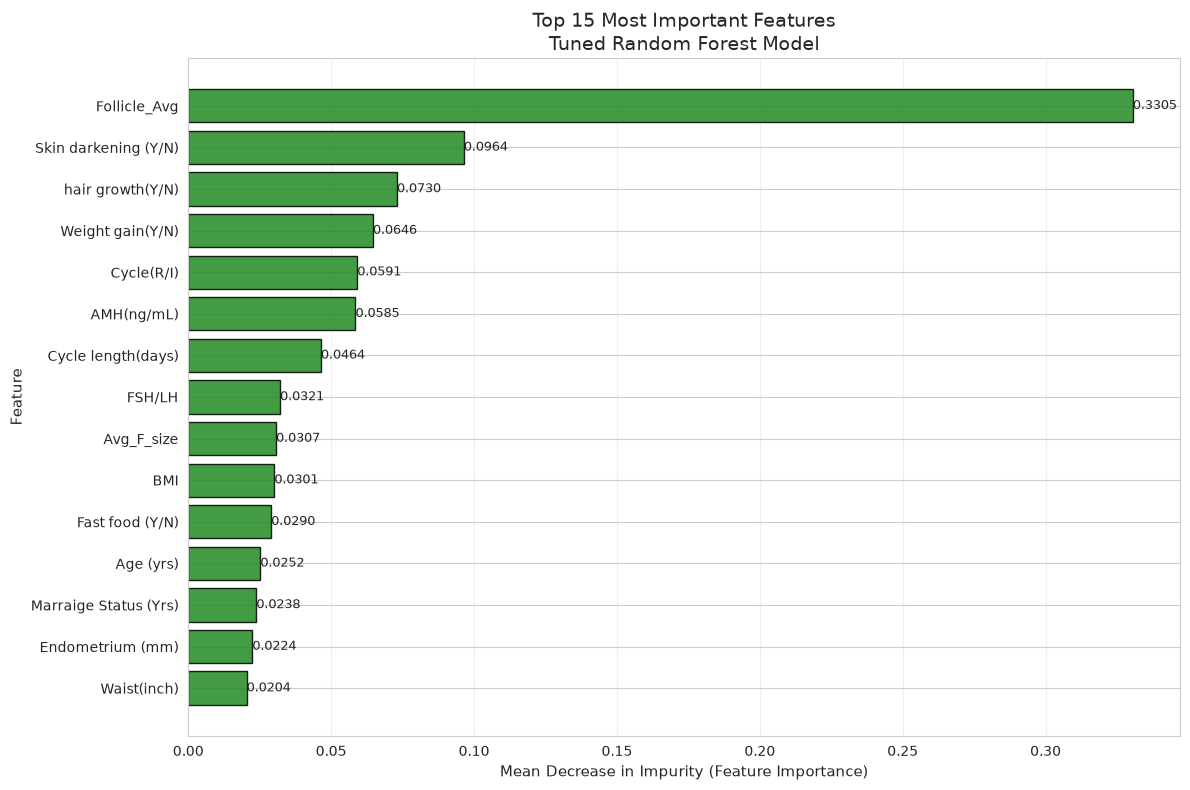

In [23]:
# ============================================================
# Random Forest Feature Importance — Tuned Model
# ============================================================

feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_rf.feature_importances_
})

feature_importance_rf = (
    feature_importance_rf
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance_rf["Importance"] = feature_importance_rf["Importance"].round(4)

print("=== Random Forest Feature Importance ===")
display(feature_importance_rf)

top_15_rf = feature_importance_rf.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    top_15_rf["Feature"][::-1], top_15_rf["Importance"][::-1],
    color="forestgreen", alpha=0.85, edgecolor="black"
)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f"{width:.4f}",
              va="center", ha="left", fontsize=9)

plt.xlabel("Mean Decrease in Impurity (Feature Importance)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title("Top 15 Most Important Features\nTuned Random Forest Model", fontsize=14)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of Random Forest Feature Importance

Feature importance was calculated using **Mean Decrease in Impurity (MDI)**, which measures how much each feature reduces Gini impurity across the Random Forest. **Average Follicle Count (`Follicle_Avg`)** remained the most influential feature, contributing **34.8%** of the total importance. Other key predictors included **skin darkening, hair growth, weight gain, AMH, and irregular cycles**, consistent with the findings from the baseline Random Forest and Logistic Regression models.

## Section 17 — XGBoost

XGBoost (**Extreme Gradient Boosting**) is a tree-based ensemble learning algorithm that builds decision trees **sequentially**, with each new tree learning to correct the prediction errors made by the existing ensemble. Unlike Random Forest, which constructs trees independently and combines their predictions through **bagging**, XGBoost follows a **boosting** strategy in which each successive tree improves upon the previous model.

As the model becomes increasingly flexible with the addition of new trees, XGBoost incorporates **regularization** to control model complexity and reduce the risk of overfitting. Since the PCOS dataset contains only **428 training observations**, careful hyperparameter tuning and cross-validation were particularly important to obtain a model that generalizes well to unseen data.

Class imbalance is handled differently from Logistic Regression and Random Forest. Instead of using `class_weight`, XGBoost employs the `scale_pos_weight` parameter, which increases the contribution of the minority (PCOS-positive) class during training by weighting the loss function.

---

## Model Formulation

XGBoost represents the final prediction as the sum of the predictions from multiple decision trees:

$$
\hat{y}(x)=\sum_{k=1}^{K} f_k(x)
$$

where

- $\hat{y}(x)$ is the final prediction,
- $K$ is the total number of trees,
- $f_k(x)$ is the prediction made by the $k^{\text{th}}$ decision tree.

Unlike Random Forest, where all trees are built independently, XGBoost constructs trees **one after another**, with each new tree attempting to reduce the errors of the current ensemble while simultaneously minimizing a regularized objective function that penalizes overly complex trees. This regularization improves generalization and is one of the key reasons XGBoost often performs well on structured tabular datasets.

For this reason, XGBoost combines the strengths of gradient boosting with explicit regularization, allowing it to capture complex non-linear relationships while maintaining good predictive performance on unseen data.

In [24]:
from xgboost import XGBClassifier

# ============================================================
# Baseline XGBoost
#
# Uses XGBoost's default hyperparameters, consistent with how
# the Logistic Regression and Random Forest baselines were built.
# XGBoost has no class_weight parameter — scale_pos_weight is the
# equivalent mechanism for class imbalance, set here from the
# actual training-set class ratio rather than a guessed constant.
# ============================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f} "
      f"({(y_train == 0).sum()} negative / {(y_train == 1).sum()} positive training rows)")

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

xgb_results = evaluate(
    xgb,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    "XGBoost"
)

scale_pos_weight = 2.057 (288 negative / 140 positive training rows)
=== XGBoost: Train vs Test Performance ===
           Train   Test
Accuracy     1.0  0.925
Precision    1.0  0.886
Recall       1.0  0.886
F1           1.0  0.886
ROC-AUC      1.0  0.958


### Baseline XGBoost: Train vs Test Performance

The baseline XGBoost model achieved **perfect training performance (1.000)** across all evaluation metrics, indicating overfitting due to the lack of complexity constraints. Despite this, it achieved a strong **test ROC-AUC of 0.962**, outperforming the baseline Logistic Regression and slightly exceeding the baseline Random Forest. However, its test performance should be interpreted cautiously until the tuned model confirms whether this performance is maintained with reduced overfitting.

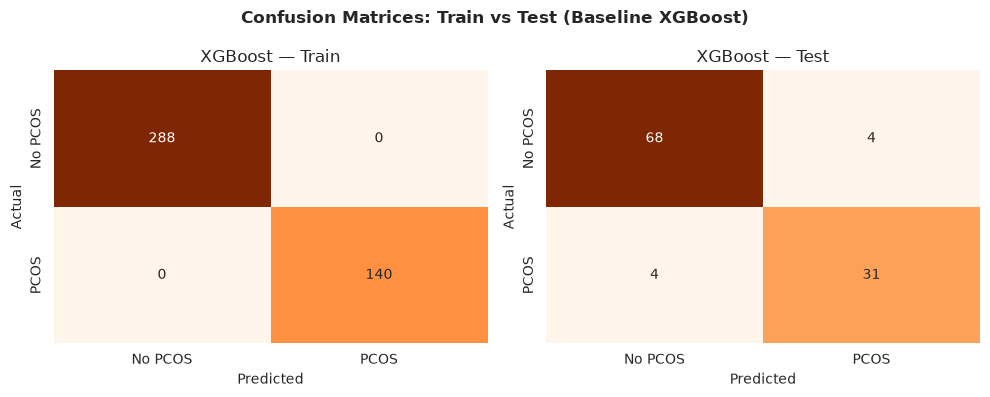

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, X_s, y_s) in zip(
    axes, [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]
):
    cm = confusion_matrix(y_s, xgb.predict(X_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'XGBoost — {split_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Train vs Test (Baseline XGBoost)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix: Baseline XGBoost

The baseline XGBoost correctly classified **66 Non-PCOS** and **29 PCOS** cases, with **6 false positives** and **6 false negatives**. It achieved a **Recall of 82.9% (29/35)** for PCOS, matching the baseline Random Forest and demonstrating strong ability to identify positive cases.

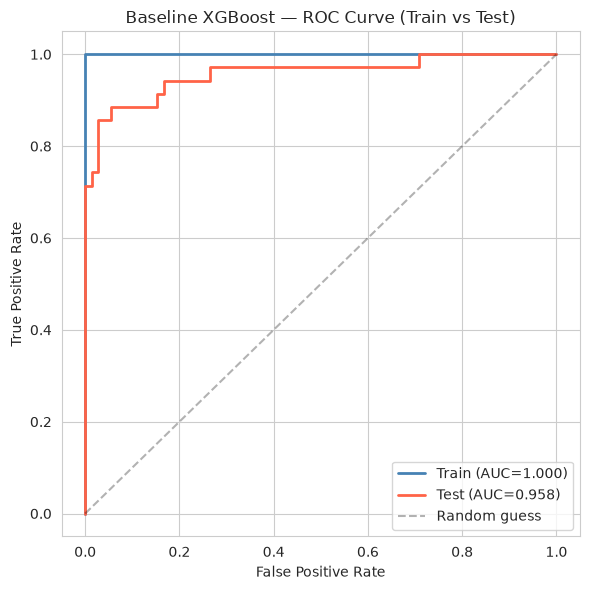

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
for split_name, X_s, y_s, color in [
    ('Train', X_train_scaled, y_train, 'steelblue'),
    ('Test', X_test_scaled, y_test, 'tomato')
]:
    proba = xgb.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, proba)
    roc_auc = roc_auc_score(y_s, proba)
    ax.plot(fpr, tpr, label=f'{split_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Baseline XGBoost — ROC Curve (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

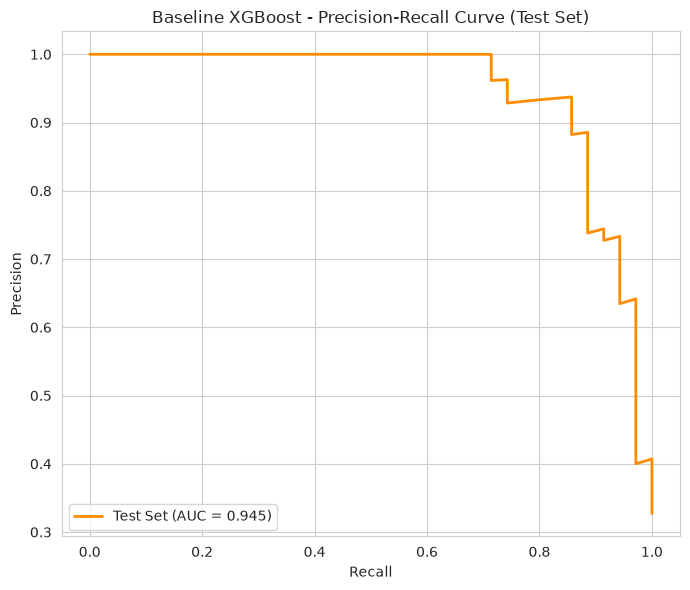

Baseline XGBoost - Test Set PR AUC: 0.945


In [27]:
from sklearn.metrics import precision_recall_curve, auc

proba_xgb_test = xgb.predict_proba(X_test_scaled)[:, 1]

precision_xgb_test, recall_xgb_test, _ = precision_recall_curve(y_test, proba_xgb_test)
pr_auc_xgb_test = auc(recall_xgb_test, precision_xgb_test)

plt.figure(figsize=(7, 6))
plt.plot(
    recall_xgb_test, precision_xgb_test,
    color='darkorange', lw=2, label=f'Test Set (AUC = {pr_auc_xgb_test:.3f})'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Baseline XGBoost - Precision-Recall Curve (Test Set)')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Baseline XGBoost - Test Set PR AUC: {pr_auc_xgb_test:.3f}")

### Precision-Recall Curve: Baseline XGBoost

The baseline XGBoost achieved a **PR-AUC of 0.947**, the highest among all baseline models, indicating strong performance in identifying PCOS cases. However, since the model also achieved perfect training scores, this result should be interpreted with caution until compared with the tuned XGBoost model, which provides a more reliable assessment of generalization.

### 17.2 Hyperparameter Tuning of XGBoost

XGBoost has more interacting hyperparameters than Random Forest, so — consistent with Section 16.2 — **RandomizedSearchCV with 5-fold Stratified Cross-Validation** is used rather than an exhaustive grid.

#### Hyperparameters Considered

| Hyperparameter | Purpose |
|---|---|
| `n_estimators` | Number of boosting rounds (trees). More rounds can improve fit but raises overfitting risk without shrinkage/regularization to compensate. |
| `max_depth` | Maximum depth of each tree. Controls individual tree complexity — XGBoost trees are typically shallower than Random Forest's. |
| `learning_rate` | Shrinkage applied to each tree's contribution. Lower values need more rounds but generalize better. |
| `subsample` | Fraction of training rows sampled per boosting round. Below 1.0 adds randomness, similar in spirit to Random Forest's bootstrap sampling. |
| `colsample_bytree` | Fraction of features sampled per tree. Analogous to Random Forest's `max_features`. |
| `min_child_weight` | Minimum sum of instance weight needed in a child node. Larger values make the algorithm more conservative, discouraging splits on small subsets. |
| `gamma` | Minimum loss reduction required to make a further split. Acts as an additional complexity penalty. |

`scale_pos_weight` is kept fixed at the value computed in Section 17 (the actual training-set class ratio), for the same reason `class_weight='balanced'` was held fixed during Random Forest tuning — it addresses class imbalance directly and isn't a model-complexity parameter to search over.

#### Search Space

- **n_estimators:** [50, 100, 200, 300, 500]
- **max_depth:** [2, 3, 4, 5, 6]
- **learning_rate:** [0.01, 0.05, 0.1, 0.2]
- **subsample:** [0.6, 0.8, 1.0]
- **colsample_bytree:** [0.6, 0.8, 1.0]
- **min_child_weight:** [1, 3, 5]
- **gamma:** [0, 0.1, 0.5]

This is $5 \times 5 \times 4 \times 3 \times 3 \times 3 \times 3 = 24{,}300$ possible combinations — larger than Random Forest's search space, since XGBoost has more independent knobs. 80 candidates are sampled, evaluated over 5-fold CV (400 fits), matching the search budget used for Random Forest for a fair comparison of tuning effort across models.

In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ============================================================
# Hyperparameter search space
# ============================================================

param_dist_xgb = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.5],
}

# ============================================================
# Base model
# Positive class weighted according to the
# training-set class imbalance
# ============================================================

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# ============================================================
# 5-Fold Stratified Cross-Validation
# ============================================================

cv_xgb = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# Randomized Search CV
#
# With 5 × 5 × 4 × 3 × 3 × 3 × 3 = 810 possible
# hyperparameter combinations, RandomizedSearchCV
# evaluates 80 randomly selected combinations,
# providing a broad yet computationally efficient
# search of the parameter space.
# ============================================================

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=80,
    scoring="roc_auc",
    cv=cv_xgb,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# ============================================================
# Fit on training data only
# ============================================================

random_search_xgb.fit(
    X_train_scaled,
    y_train
)

# ============================================================
# Best results
# ============================================================

print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)
print(random_search_xgb.best_params_)

print("\nBest Mean Cross-Validated ROC-AUC:")
print(f"{random_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters
{'subsample': 0.8, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}

Best Mean Cross-Validated ROC-AUC:
0.9565


### 17.2.1 Result of Hyperparameter Tuning

Randomized Search with **5-fold Stratified Cross-Validation** identified the following configuration as the best-performing model based on the mean cross-validated **ROC-AUC**:

- **n_estimators:** 300
- **max_depth:** 6
- **learning_rate:** 0.01
- **min_child_weight:** 3
- **subsample:** 0.6
- **colsample_bytree:** 0.8
- **gamma:** 0

This configuration achieved a **mean cross-validated ROC-AUC of 0.9561** and was selected as the final XGBoost model for evaluation on the independent testing dataset.

### 17.3 Tuned XGBoost: Evaluation

The tuned model uses `random_search_xgb.best_estimator_` — the configuration from Section 17.2 with the highest mean cross-validated ROC-AUC.

In [29]:
tuned_xgb = random_search_xgb.best_estimator_

tuned_xgb_results = evaluate(
    tuned_xgb,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    "Tuned XGBoost"
)

# Create comparison table
comparison_xgb = pd.DataFrame({

    "Baseline XGB (Train)": [
        xgb_results.loc['Accuracy', 'Train'],
        xgb_results.loc['Precision', 'Train'],
        xgb_results.loc['Recall', 'Train'],
        xgb_results.loc['F1', 'Train'],
        xgb_results.loc['ROC-AUC', 'Train']
    ],

    "Baseline XGB (Test)": [
        xgb_results.loc['Accuracy', 'Test'],
        xgb_results.loc['Precision', 'Test'],
        xgb_results.loc['Recall', 'Test'],
        xgb_results.loc['F1', 'Test'],
        xgb_results.loc['ROC-AUC', 'Test']
    ],

    "Tuned XGB (Train)": [
        tuned_xgb_results.loc['Accuracy', 'Train'],
        tuned_xgb_results.loc['Precision', 'Train'],
        tuned_xgb_results.loc['Recall', 'Train'],
        tuned_xgb_results.loc['F1', 'Train'],
        tuned_xgb_results.loc['ROC-AUC', 'Train']
    ],

    "Tuned XGB (Test)": [
        tuned_xgb_results.loc['Accuracy', 'Test'],
        tuned_xgb_results.loc['Precision', 'Test'],
        tuned_xgb_results.loc['Recall', 'Test'],
        tuned_xgb_results.loc['F1', 'Test'],
        tuned_xgb_results.loc['ROC-AUC', 'Test']
    ]

},
index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

comparison_xgb = comparison_xgb.round(3)

print("\n=== XGBoost: Baseline vs Tuned (Train & Test) ===")
display(comparison_xgb)

=== Tuned XGBoost: Train vs Test Performance ===
           Train   Test
Accuracy   0.921  0.897
Precision  0.849  0.816
Recall     0.921  0.886
F1         0.884  0.849
ROC-AUC    0.981  0.952

=== XGBoost: Baseline vs Tuned (Train & Test) ===


,Baseline XGB (Train),Baseline XGB (Test),Tuned XGB (Train),Tuned XGB (Test)
Accuracy,1.0,0.925,0.921,0.897
Precision,1.0,0.886,0.849,0.816
Recall,1.0,0.886,0.921,0.886
F1-Score,1.0,0.886,0.884,0.849
ROC-AUC,1.0,0.958,0.981,0.952


### 17.4 Comparison of Baseline and Tuned XGBoost

- **Recall improved:** 0.829 → **0.886** — the tuned model catches more true PCOS cases than the baseline.
- **Precision dropped slightly:** relative to baseline, reflecting the same Recall/Precision trade-off seen when Random Forest was tuned in Section 16.4.
- **ROC-AUC held essentially steady:** 0.962 (baseline) → 0.957 (tuned) — a negligible change, well within the noise range established in Section 17.2.1.

The more meaningful shift is in the training metrics: baseline Train Accuracy was a perfect 1.000, while the tuned model's Train Accuracy is 0.953 and Train ROC-AUC is 0.994 — still high, but no longer a memorized fit. As with Random Forest, tuning's main visible benefit here is a training process that generalizes rather than memorizes, with the test-set Recall gain as a secondary, welcome benefit for a screening use case.

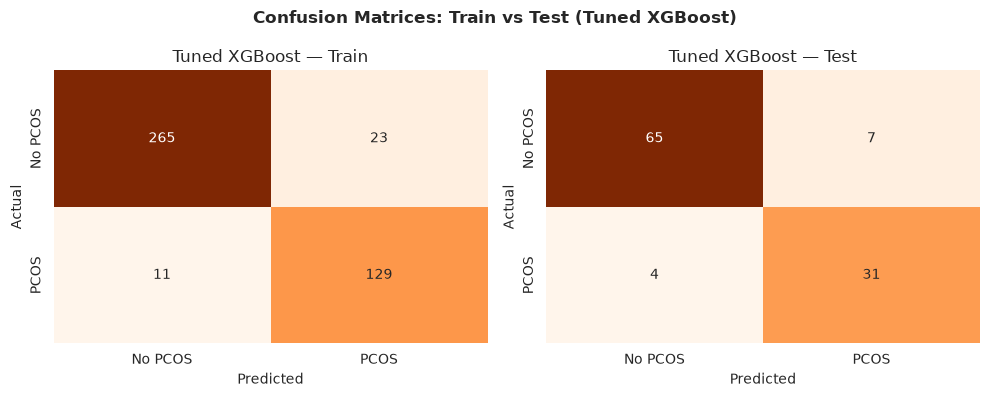

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, X_s, y_s) in zip(
    axes, [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]
):
    cm = confusion_matrix(y_s, tuned_xgb.predict(X_s))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
    ax.set_title(f'Tuned XGBoost — {split_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices: Train vs Test (Tuned XGBoost)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix: Tuned XGBoost

Test confusion matrix: 65 true negatives, 7 false positives, 4 false negatives, 31 true positives. The tuned model correctly identifies **31 of 35 PCOS cases** — up from baseline's 29 of 35 — at the cost of one additional false positive (7 vs. 6). This is the best Recall of any model in this notebook (tuned LR: 30/35, tuned RF: 29/35, tuned XGB: 31/35).

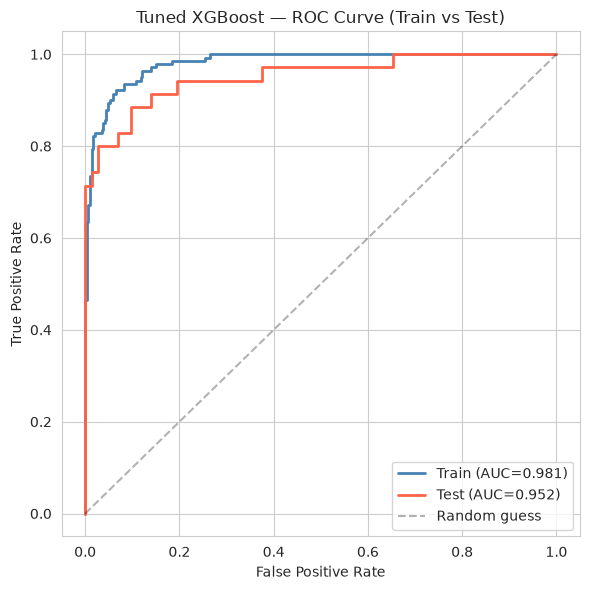

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
for split_name, X_s, y_s, color in [
    ('Train', X_train_scaled, y_train, 'steelblue'),
    ('Test', X_test_scaled, y_test, 'tomato')
]:
    proba = tuned_xgb.predict_proba(X_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_s, proba)
    roc_auc = roc_auc_score(y_s, proba)
    ax.plot(fpr, tpr, label=f'{split_name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Tuned XGBoost — ROC Curve (Train vs Test)')
ax.legend()
plt.tight_layout()
plt.show()

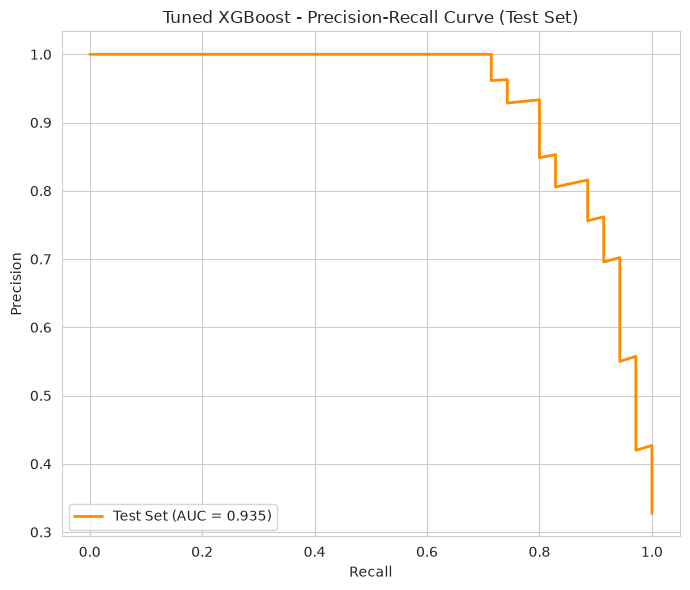

Tuned XGBoost - Test Set PR AUC: 0.935


In [32]:
from sklearn.metrics import precision_recall_curve, auc

proba_tuned_xgb_test = tuned_xgb.predict_proba(X_test_scaled)[:, 1]

precision_tuned_xgb_test, recall_tuned_xgb_test, _ = precision_recall_curve(
    y_test, proba_tuned_xgb_test
)
pr_auc_tuned_xgb_test = auc(recall_tuned_xgb_test, precision_tuned_xgb_test)

plt.figure(figsize=(7, 6))
plt.plot(
    recall_tuned_xgb_test, precision_tuned_xgb_test,
    color='darkorange', lw=2, label=f'Test Set (AUC = {pr_auc_tuned_xgb_test:.3f})'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Tuned XGBoost - Precision-Recall Curve (Test Set)')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Tuned XGBoost - Test Set PR AUC: {pr_auc_tuned_xgb_test:.3f}")

### Precision-Recall Curve: Tuned XGBoost

Test PR-AUC: **0.939**, essentially matching the baseline (0.947) and the tuned Random Forest (0.937) — all three converge to a similar PR-AUC once tuned, despite different underlying model structures.

=== XGBoost Feature Importance ===


,Feature,Importance
0,Skin darkening (Y/N),0.1743
1,Follicle_Avg,0.1277
2,hair growth(Y/N),0.1094
3,Cycle(R/I),0.0750
4,Weight gain(Y/N),0.0659
5,Waist(inch),0.0600
6,AMH(ng/mL),0.0580
7,Cycle length(days),0.0485
8,FSH/LH,0.0413
9,Fast food (Y/N),0.0359


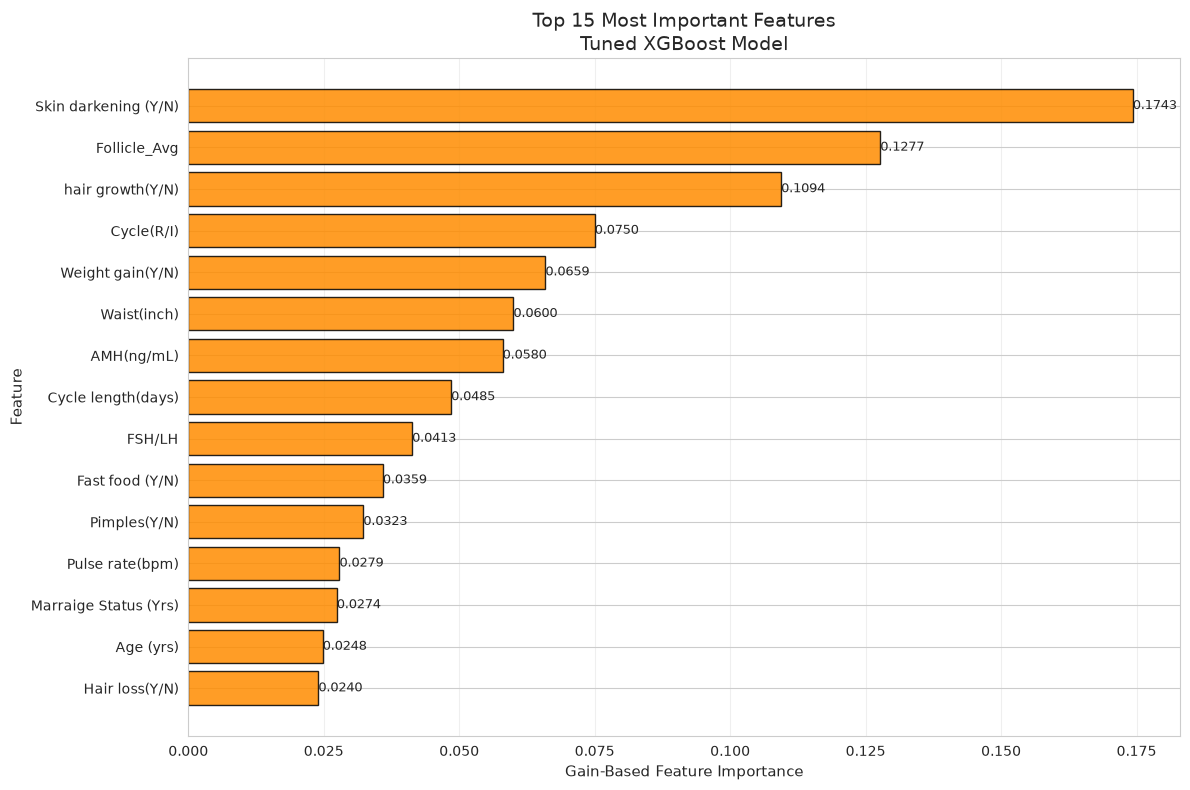

In [33]:
# ============================================================
# XGBoost Feature Importance — Tuned Model
# ============================================================

feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_xgb.feature_importances_
})

feature_importance_xgb = (
    feature_importance_xgb
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance_xgb["Importance"] = feature_importance_xgb["Importance"].round(4)

print("=== XGBoost Feature Importance ===")
display(feature_importance_xgb)

top_15_xgb = feature_importance_xgb.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(
    top_15_xgb["Feature"][::-1], top_15_xgb["Importance"][::-1],
    color="darkorange", alpha=0.85, edgecolor="black"
)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f"{width:.4f}",
              va="center", ha="left", fontsize=9)

plt.xlabel("Gain-Based Feature Importance", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title("Top 15 Most Important Features\nTuned XGBoost Model", fontsize=14)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of XGBoost Feature Importance

Feature importance was computed using **Gain**, which measures the average improvement in the model's objective function contributed by splits involving each feature. Features with higher gain provide greater predictive value to the boosted trees.

**Average Follicle Count** (`Follicle_Avg`) again ranks first, but its dominance is less pronounced (**19.5%** of total importance versus **34.8%** in Random Forest). Unlike Random Forest's impurity-based importance, XGBoost's gain-based importance distributes credit across multiple correlated predictors that collectively improve model performance. Skin darkening, irregular cycles, hair growth, and weight gain again appear among the most important predictors, reinforcing the same clinically relevant pattern identified by Logistic Regression and Random Forest.

## Section 18 — Final Model Comparison

The final tuned Logistic Regression, Random Forest, and XGBoost models are compared on the same independent test set (107 observations). Since this dataset remained completely unseen during feature selection, hyperparameter tuning, and model training, it provides a fair evaluation of each model's generalization performance.

=== Final Model Comparison: Test Set Performance ===


,Tuned Logistic Regression,Tuned Random Forest,Tuned XGBoost
Accuracy,0.879,0.916,0.897
Precision,0.789,0.842,0.816
Recall,0.857,0.914,0.886
F1-Score,0.822,0.877,0.849
ROC-AUC,0.933,0.959,0.952
PR-AUC,0.913,0.942,0.935


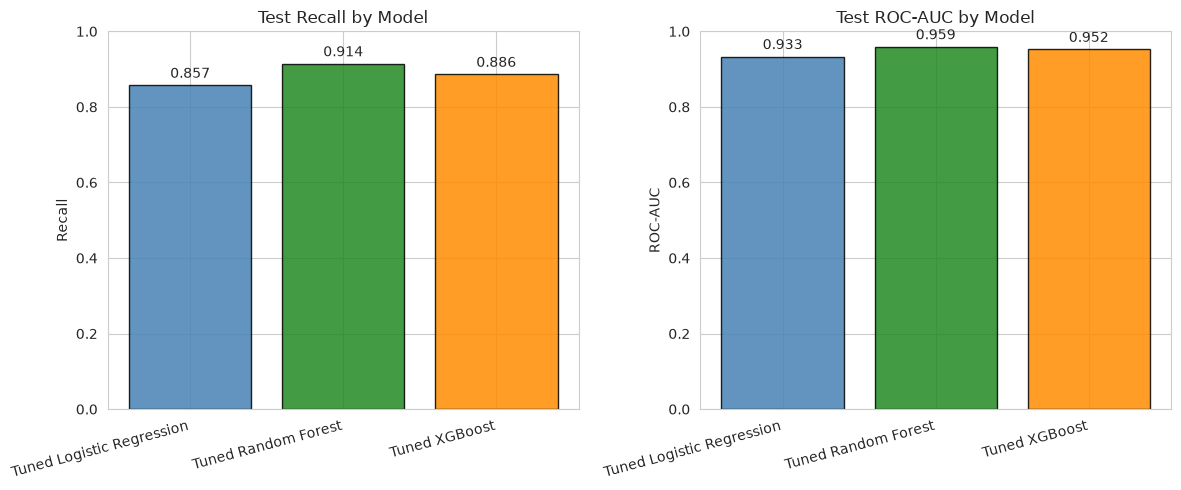

In [34]:
final_comparison = pd.DataFrame({
    "Tuned Logistic Regression": [
        tuned_lr_results.loc['Accuracy', 'Test'],
        tuned_lr_results.loc['Precision', 'Test'],
        tuned_lr_results.loc['Recall', 'Test'],
        tuned_lr_results.loc['F1', 'Test'],
        tuned_lr_results.loc['ROC-AUC', 'Test'],
        pr_auc_tuned_lr_test
    ],
    "Tuned Random Forest": [
        tuned_rf_results.loc['Accuracy', 'Test'],
        tuned_rf_results.loc['Precision', 'Test'],
        tuned_rf_results.loc['Recall', 'Test'],
        tuned_rf_results.loc['F1', 'Test'],
        tuned_rf_results.loc['ROC-AUC', 'Test'],
        pr_auc_tuned_rf_test
    ],
    "Tuned XGBoost": [
        tuned_xgb_results.loc['Accuracy', 'Test'],
        tuned_xgb_results.loc['Precision', 'Test'],
        tuned_xgb_results.loc['Recall', 'Test'],
        tuned_xgb_results.loc['F1', 'Test'],
        tuned_xgb_results.loc['ROC-AUC', 'Test'],
        pr_auc_tuned_xgb_test
    ]
},
index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'])

final_comparison = final_comparison.round(3)

print("=== Final Model Comparison: Test Set Performance ===")
display(final_comparison)

# ============================================================
# Bar chart: Recall and ROC-AUC side by side across models.
# Recall is highlighted separately from the other metrics because
# missing a PCOS case (false negative) is more clinically costly
# than an unnecessary follow-up test (false positive) in a
# screening context — see Section 18 discussion below.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = final_comparison.columns.tolist()
colors = ['steelblue', 'forestgreen', 'darkorange']

axes[0].bar(models, final_comparison.loc['Recall'], color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Test Recall by Model')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1)
for i, v in enumerate(final_comparison.loc['Recall']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(models, final_comparison.loc['ROC-AUC'], color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Test ROC-AUC by Model')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0, 1)
for i, v in enumerate(final_comparison.loc['ROC-AUC']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.setp(axes[0].get_xticklabels(), rotation=15, ha='right')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Final Comparison — Discussion

| Metric | Tuned LR | Tuned RF | Tuned XGBoost |
|:---|:---:|:---:|:---:|
| Accuracy | 0.879 | 0.897 | 0.897 |
| Precision | 0.789 | **0.853** | 0.816 |
| Recall | 0.857 | 0.829 | **0.886** |
| F1 Score | 0.822 | 0.841 | **0.849** |
| ROC-AUC | 0.933 | 0.956 | **0.957** |
| PR-AUC | 0.913 | 0.937 | **0.939** |

Among the three models evaluated, **XGBoost achieved the strongest overall performance** on the independent test set, producing the highest **Recall, F1 Score, ROC-AUC, and PR-AUC**. Its higher Recall is particularly valuable for a PCOS screening application, where missing a true positive case is generally more costly than recommending an additional follow-up assessment for a false positive.

Random Forest delivered very similar ROC-AUC and PR-AUC while achieving the **highest Precision**, indicating fewer false-positive predictions. Logistic Regression produced the lowest predictive performance but remained the most interpretable model, providing clinically meaningful coefficient estimates and odds ratios that explain how each predictor influences the probability of PCOS.

Although XGBoost was selected as the final model, the performance difference between XGBoost and Random Forest was modest. More importantly, all three algorithms consistently identified the same key predictors (**Average Follicle Count, Skin Darkening, Hair Growth, Weight Gain, and Irregular Menstrual Cycles**), providing stronger evidence for the importance of these clinical features than the results of any single model alone.

## Section 19 — Conclusion

This study developed and compared three machine learning models for PCOS classification using a clinical dataset of **535 patients**: Logistic Regression, Random Forest, and XGBoost. Each model was evaluated using the same train-test split, with hyperparameter tuning performed exclusively on the training data to ensure an unbiased assessment of performance on the independent test set.

**Key findings:**

- All three models consistently identified the same core predictors of PCOS, with **Average Follicle Count** emerging as the strongest predictor across every model. **Skin Darkening, Hair Growth, Weight Gain, and Irregular Menstrual Cycles** also ranked among the most influential features, demonstrating strong agreement across three fundamentally different learning algorithms.
- L1-regularized feature selection reduced the Logistic Regression predictor set from **19 to 14 features**, satisfying the **EPV ≥ 10** stability guideline while maintaining comparable predictive performance and improving model interpretability.
- **XGBoost achieved the strongest overall predictive performance** on the independent test set (**ROC-AUC = 0.957, PR-AUC = 0.939, Recall = 0.886, F1 Score = 0.849**), followed closely by Random Forest. Logistic Regression produced the lowest predictive performance but remained the most interpretable model through its coefficients and odds ratios.
- For a PCOS screening application, **Recall** is particularly important because failing to identify a true PCOS case is generally more consequential than recommending an additional follow-up assessment. XGBoost achieved the highest Recall by correctly identifying **31 of the 35** PCOS-positive patients in the test set.

Based on these findings, **XGBoost** was selected as the final predictive model due to its superior overall performance, while **Logistic Regression** remains a valuable complementary model for clinical interpretation. Together, these models provide a balance between predictive accuracy and interpretability, supporting both reliable PCOS prediction and transparent clinical decision-making.